# Pedestrian Crash Severity Prediction in London
## Integrating Road Network Topology Features with Machine Learning

**Course:** CASA0006 / [Your Course Code]  
**Student:** [Your Name]  
**Date:** April 2026

---

## Abstract

> This notebook investigates pedestrian crash severity prediction in London using five years of STATS19 data (2019–2023). We address two limitations common in the literature: (1) the tendency to merge Fatal and Serious injury classes, which obscures policy-relevant distinctions; and (2) the neglect of road network topology as a predictor of crash outcomes. We introduce edge betweenness centrality as a novel feature representing road segment traffic flow potential, and systematically compare prediction performance with and without this network feature. Given the severe class imbalance in the dataset (Fatal: 1.2%, Serious: 25.7%, Slight: 73.4%), we employ class weighting, joint threshold optimisation, and evaluate models using G-mean and macro F1-score rather than accuracy. Results show that [to be completed].

---

## Table of Contents

1. [Research Context and Questions](#1-research-context-and-questions)
2. [Data Collection and Preparation](#2-data-collection-and-preparation)
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)
4. [Network Feature Engineering](#4-network-feature-engineering)
5. [Methodology](#5-methodology)
6. [Series A: Baseline Models (STATS19 Features Only)](#6-series-a-baseline-models)
7. [Series B: Enhanced Models (+ Network Features)](#7-series-b-enhanced-models)
8. [Results and Comparison](#8-results-and-comparison)
9. [Interpretability: SHAP Analysis](#9-interpretability-shap-analysis)
10. [Discussion](#10-discussion)
11. [Conclusion](#11-conclusion)

---
## 1. Research Context and Research Questions
*(Marking criterion: Analysis context and research questions — 15%)*

### 1.1 Background

Pedestrians represent one of the most vulnerable road user groups. In Great Britain, pedestrians accounted for approximately 24% of all road deaths in 2021 (Department for Transport, 2022). Understanding the factors that determine whether a pedestrian-vehicle collision results in a slight, serious, or fatal injury is essential for Vision Zero policy and emergency resource allocation.

Machine learning approaches to crash severity prediction have grown substantially since 2018, but two methodological gaps persist in the literature:

1. **Class merging**: Most studies merge Fatal and Serious injury classes to mitigate class imbalance (e.g., Fiorentini & Losa, 2020), losing policy-relevant granularity.
2. **Feature scope**: Existing studies rely almost exclusively on STATS19 tabular features (weather, road type, speed limit), ignoring the structural properties of the road network in which crashes occur.

This study addresses both gaps by maintaining three distinct severity classes and introducing **edge betweenness centrality** — a measure of road segment importance in the network — as a novel predictor.

### 1.2 Research Questions

> **RQ1:** Can machine learning models accurately predict pedestrian crash severity across three distinct classes (Fatal, Serious, Slight) without merging categories, while appropriately handling class imbalance?

> **RQ2:** Does the inclusion of road network topology features — specifically edge betweenness centrality — improve crash severity prediction performance beyond STATS19 features alone?

> **RQ3:** Which features are most influential in determining pedestrian crash severity, and what are the implications for road safety policy in London?

### 1.3 Conceptual Framework

```
STATS19 Features          Road Network Features
(speed, light, weather)   (betweenness centrality)
        |                          |
        └──────────┬───────────────┘
                   ▼
        Machine Learning Model
        (RF / XGBoost)
                   ▼
        Severity Prediction
        Fatal / Serious / Slight
                   ▼
        Policy Implications
        (infrastructure, emergency response)
```

---
## 2. Data Collection and Preparation
*(Marking criterion: Data collection, handling, and presentation — 15%)*

### 2.1 Data Sources

| Dataset | Source | Coverage | Variables Used |
|---------|--------|----------|----------------|
| STATS19 Collisions | DfT Open Data | 2019–2023 | severity, speed, weather, light, road type, junction |
| STATS19 Casualties | DfT Open Data | 2019–2023 | casualty_severity, vehicle_type, age_of_vehicle |
| STATS19 Vehicles | DfT Open Data | 2019–2023 | ---------, ---------, --------- |
| OS Road Network | OSMnx (OpenStreetMap) | Greater London | geometry, edge betweenness centrality |

### 2.2 Data Loading

In [1]:
# ── Core Libraries ────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Spatial Libraries ─────────────────────────────────────────────────────────
import osmnx as ox
import networkx as nx
import igraph as ig
from shapely.geometry import Point

# ── ML Libraries ──────────────────────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, recall_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from imblearn.metrics import geometric_mean_score
import shap

# ── Plot Settings ─────────────────────────────────────────────────────────────
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'
COLORS = {'Fatal': '#d62728', 'Serious': '#ff7f0e', 'Slight': '#2ca02c'}

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# ── Load STATS19 Data ─────────────────────────────────────────────────────────

# Load London LSOA (Lower Layer Super Output Area) boundaries to define the geographic study area
lon_lsoa = gpd.read_file('../Data/statistical-gis-boundaries-london/ESRI/LSOA_2011_London_gen_MHW.shp')

# Load raw collision data (contains coordinates and environmental factors)
collision = pd.read_csv('../Data/dft-road-casualty-statistics-collision-last-5-years.csv')

# Perform an inner merge to keep only accidents that occurred within London LSOA boundaries
lon_collision_5Y = lon_lsoa.merge(collision, left_on='LSOA11CD', right_on='lsoa_of_accident_location', how='inner')

# Data Deduplication: STATS19 records can sometimes overlap or be recorded multiple times
lon_collision_5Y = lon_collision_5Y.drop_duplicates(subset=["collision_ref_no"], keep='first')

# Load casualty data (contains details about people injured)
casualty = pd.read_csv('../Data/dft-road-casualty-statistics-casualty-last-5-years.csv')

# Filter for Pedestrians only (casualty_type == 0 is the code for pedestrians in STATS19)
pedestrain_casualty = casualty[casualty["casualty_type"] == 0]

# One accident can have multiple casualties. We prioritize the most severe injury 
# (Note: In STATS19, 1 = Fatal, 2 = Serious, 3 = Slight, so ascending order captures highest severity)
pedestrain_most_severe = pedestrain_casualty.sort_values(
    by=['collision_index', 'casualty_severity'], 
    ascending=[True, True]
).drop_duplicates(subset=['collision_index'], keep='first')

# Load vehicle data (contains details about engine size, vehicle age, etc.)
vehicle = pd.read_csv('../Data/dft-road-casualty-statistics-vehicle-last-5-years.csv')

# Merge filtered London collisions with the most severe pedestrian casualty records
lon_pedestrain_casualty_collision = pd.merge(pedestrain_most_severe, lon_collision_5Y, on='collision_index', how='inner')

# Join with vehicle data to identify the vehicle involved in the pedestrian hit
lon_pedestrain_collision_5y = pd.merge(lon_pedestrain_casualty_collision, vehicle, on='collision_index', how='left')

# In multi-vehicle accidents, filter for the primary vehicle (reference 1) to simplify the analysis
# to the most likely vehicle that struck the pedestrian.
lon_pedestrain_collision_5y = lon_pedestrain_collision_5y[lon_pedestrain_collision_5y["vehicle_reference_y"] == 1]

# give the table a simple name `df`
df = lon_pedestrain_collision_5y

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df['casualty_severity'].value_counts())
print(f"\nMissing values:")

Dataset shape: (19963, 112)

Class distribution:
casualty_severity
3    14614
2     5116
1      233
Name: count, dtype: int64

Missing values:


### 2.3 Data Cleaning and Feature Selection

In [3]:
# ── Missing Value Imputation ───────────────────────────────────────────────────
# STATS19 uses '-1' to represent 'Data missing or out of range'
# Converting to NaN allows for proper imputation or exclusion during machine learning
df.replace(-1, np.nan, inplace=True)

# ── Cyclic Encoding for Hour ───────────────────────────────────────────────────
# extract 'hour' from the 'time' string to create a cyclical numerical feature for the model
df['hour'] = pd.to_datetime(
    lon_pedestrain_collision_5y['time'], 
    format='%H:%M', 
    errors='coerce'
).dt.hour

# Remove original 'time' string column to maintain feature matrix integrity
df.drop(columns=['time'], inplace=True)

# Final Integrity Check: Drop rows missing the Target (severity) or spatial data (for BC mapping)
# Without coordinates, the record cannot be snapped to the road network later.
df.dropna(subset=['casualty_severity'], inplace=True)
df.dropna(subset=['longitude', 'latitude'], inplace=True)

# ── Feature Selection ─────────────────────────────────────────────────────────
cols_selected = [
    'longitude', 'latitude',                            # Spatial identifiers for network mapping                                
    'speed_limit', 'light_conditions',                  # Environmental context
    'weather_conditions', 'road_surface_conditions',
    'road_type', 'junction_detail', 'junction_control',
    'urban_or_rural_area', 'hour', 'day_of_week',
    'vehicle_type', 'engine_capacity_cc',               # Vehicle characteristics
    'age_of_vehicle', 'propulsion_code'
]
X = df[cols_selected].copy()
y = df['casualty_severity'].copy()

# Continuous variables: median imputation
X['engine_capacity_cc'] = X['engine_capacity_cc'].fillna(X['engine_capacity_cc'].median())
X['age_of_vehicle']     = X['age_of_vehicle'].fillna(X['age_of_vehicle'].median())

print(f"Final feature matrix shape: {X.shape}")
print(f"Features: {X.columns.tolist()}")
print(df.notnull().sum())

Final feature matrix shape: (19963, 16)
Features: ['longitude', 'latitude', 'speed_limit', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'road_type', 'junction_detail', 'junction_control', 'urban_or_rural_area', 'hour', 'day_of_week', 'vehicle_type', 'engine_capacity_cc', 'age_of_vehicle', 'propulsion_code']
collision_index            19963
collision_year_x           19963
collision_ref_no_x         19963
vehicle_reference_x        19963
casualty_reference         19963
                           ...  
driver_imd_decile          12600
lsoa_of_driver             19963
escooter_flag              19963
driver_distance_banding     2352
hour                       19963
Length: 112, dtype: int64


### 2.4 Train / Validation / Test Split

We use a stratified 60/20/20 split. The validation set is held out for threshold tuning only — it is never used for model training. The test set is touched only once for final evaluation.

In [4]:
# ── Stratified Split ──────────────────────────────────────────────────────────
# stratify=y ensures Fatal/Serious/Slight proportions are preserved in each split
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=63, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=63, stratify=y_temp
)

print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")
print(f"\nClass distribution in test set:")
print(y_test.value_counts().sort_index())

Train: 11,977 | Val: 3,993 | Test: 3,993

Class distribution in test set:
casualty_severity
1      47
2    1023
3    2923
Name: count, dtype: int64


---
## 3. Exploratory Data Analysis
*(Marking criterion: Correctness, depth, and scope — 35% | Visualisation — 10%)*

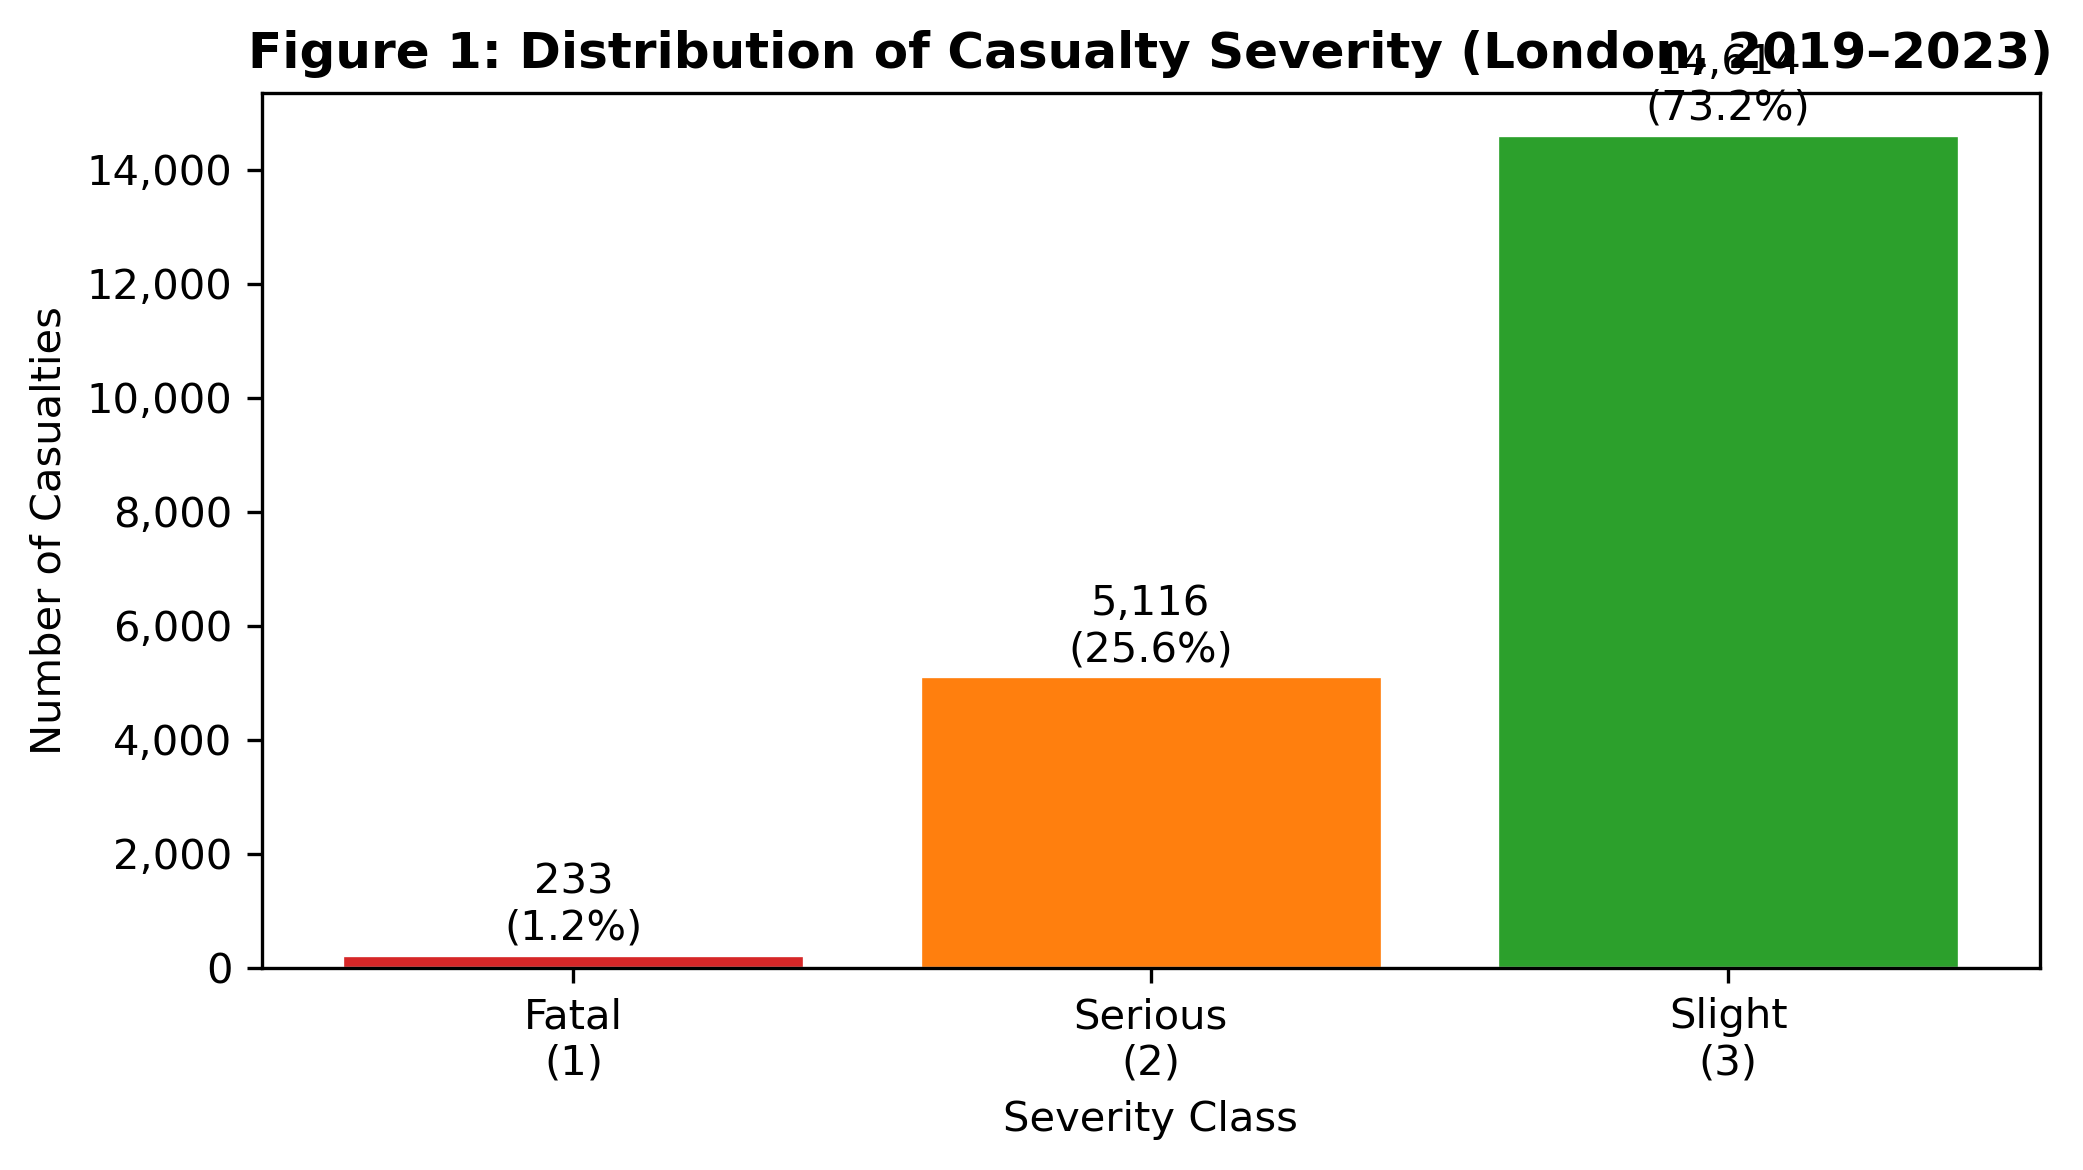


Class imbalance ratios:
  Slight:Fatal   = 63:1
  Slight:Serious = 2.9:1


In [5]:
# ── Figure 1: Class Distribution ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

counts = y.value_counts().sort_index()
bars = ax.bar(
    ['Fatal\n(1)', 'Serious\n(2)', 'Slight\n(3)'],
    counts.values,
    color=[COLORS['Fatal'], COLORS['Serious'], COLORS['Slight']],
    edgecolor='white', linewidth=0.8
)

for bar, count in zip(bars, counts.values):
    pct = count / len(y) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

ax.set_title('Figure 1: Distribution of Casualty Severity (London, 2019–2023)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Casualties')
ax.set_xlabel('Severity Class')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('../figure/fig1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nClass imbalance ratios:")
print(f"  Slight:Fatal   = {counts[3]/counts[1]:.0f}:1")
print(f"  Slight:Serious = {counts[3]/counts[2]:.1f}:1")

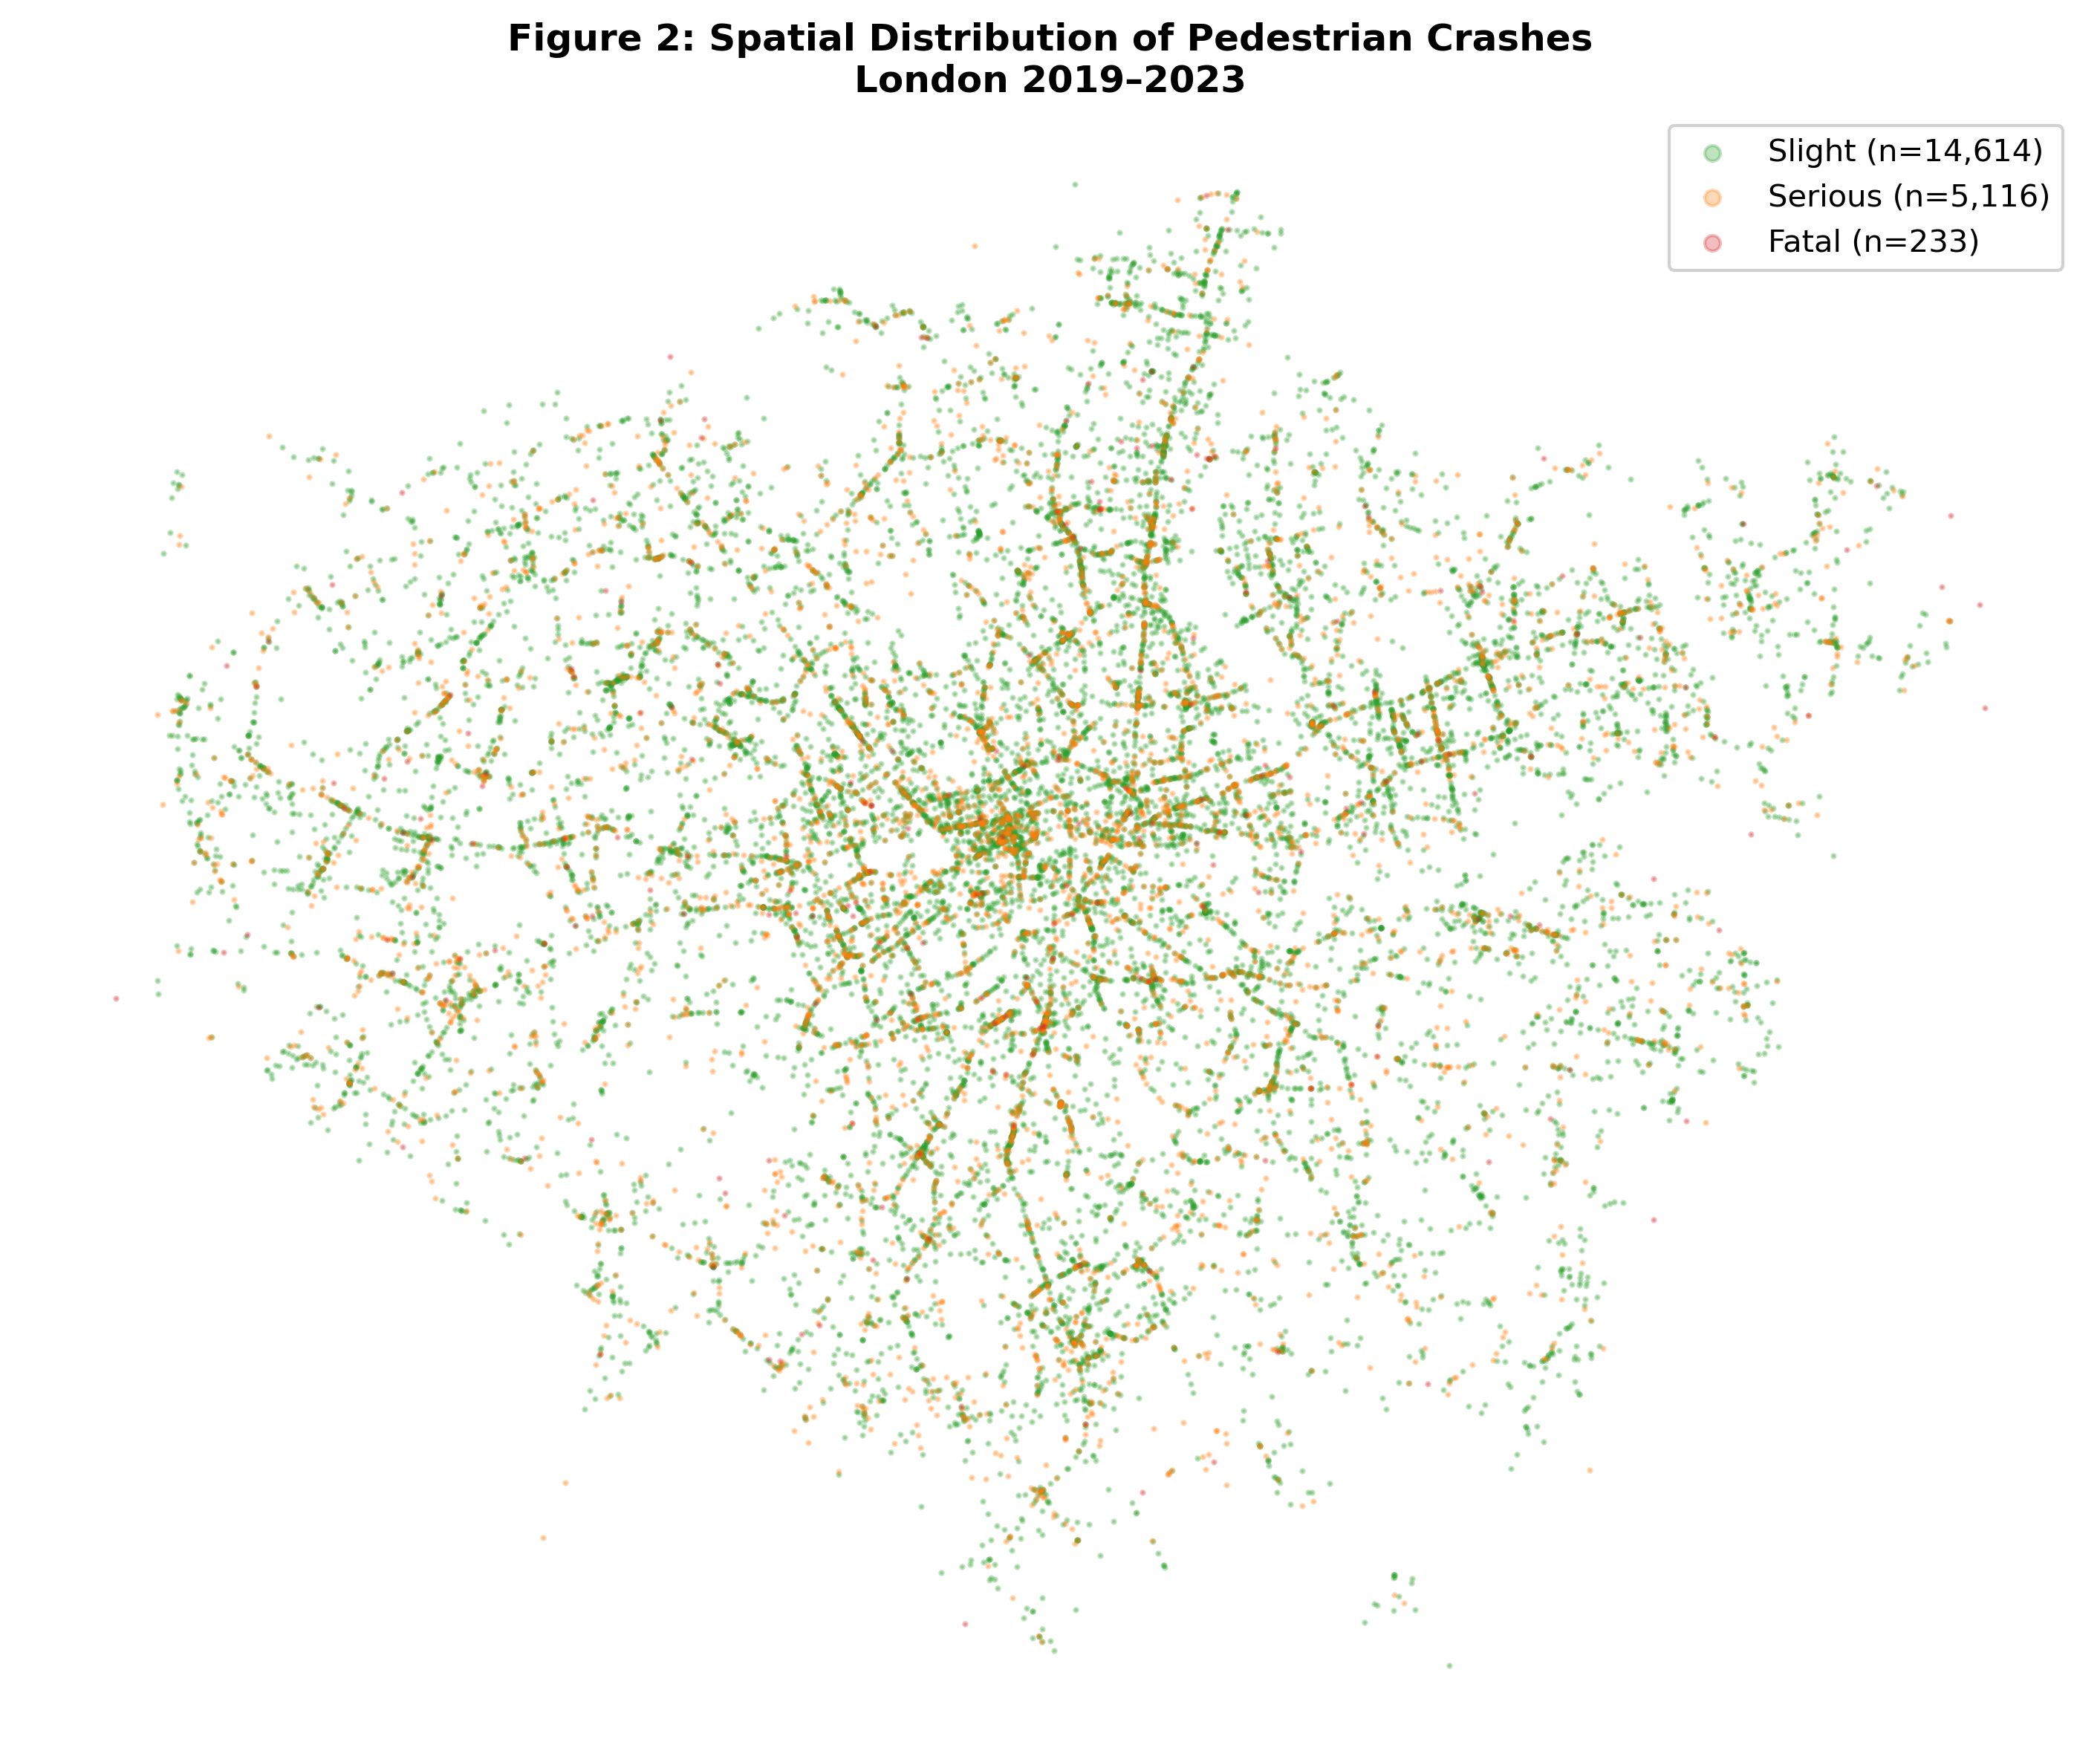

In [6]:
# ── Figure 2: Spatial Distribution of Crashes ─────────────────────────────────
gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
    crs='EPSG:4326'
)

fig, ax = plt.subplots(figsize=(10, 8))

for severity, label, color in [
    (3, 'Slight',  COLORS['Slight']),
    (2, 'Serious', COLORS['Serious']),
    (1, 'Fatal',   COLORS['Fatal'])
]:
    subset = gdf[gdf['casualty_severity'] == severity]
    subset.plot(ax=ax, markersize=1, color=color,
                alpha=0.3, label=f'{label} (n={len(subset):,})')

ax.set_title('Figure 2: Spatial Distribution of Pedestrian Crashes\nLondon 2019–2023',
             fontsize=12, fontweight='bold')
ax.legend(markerscale=5, framealpha=0.9)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('../Figure/fig2_spatial_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

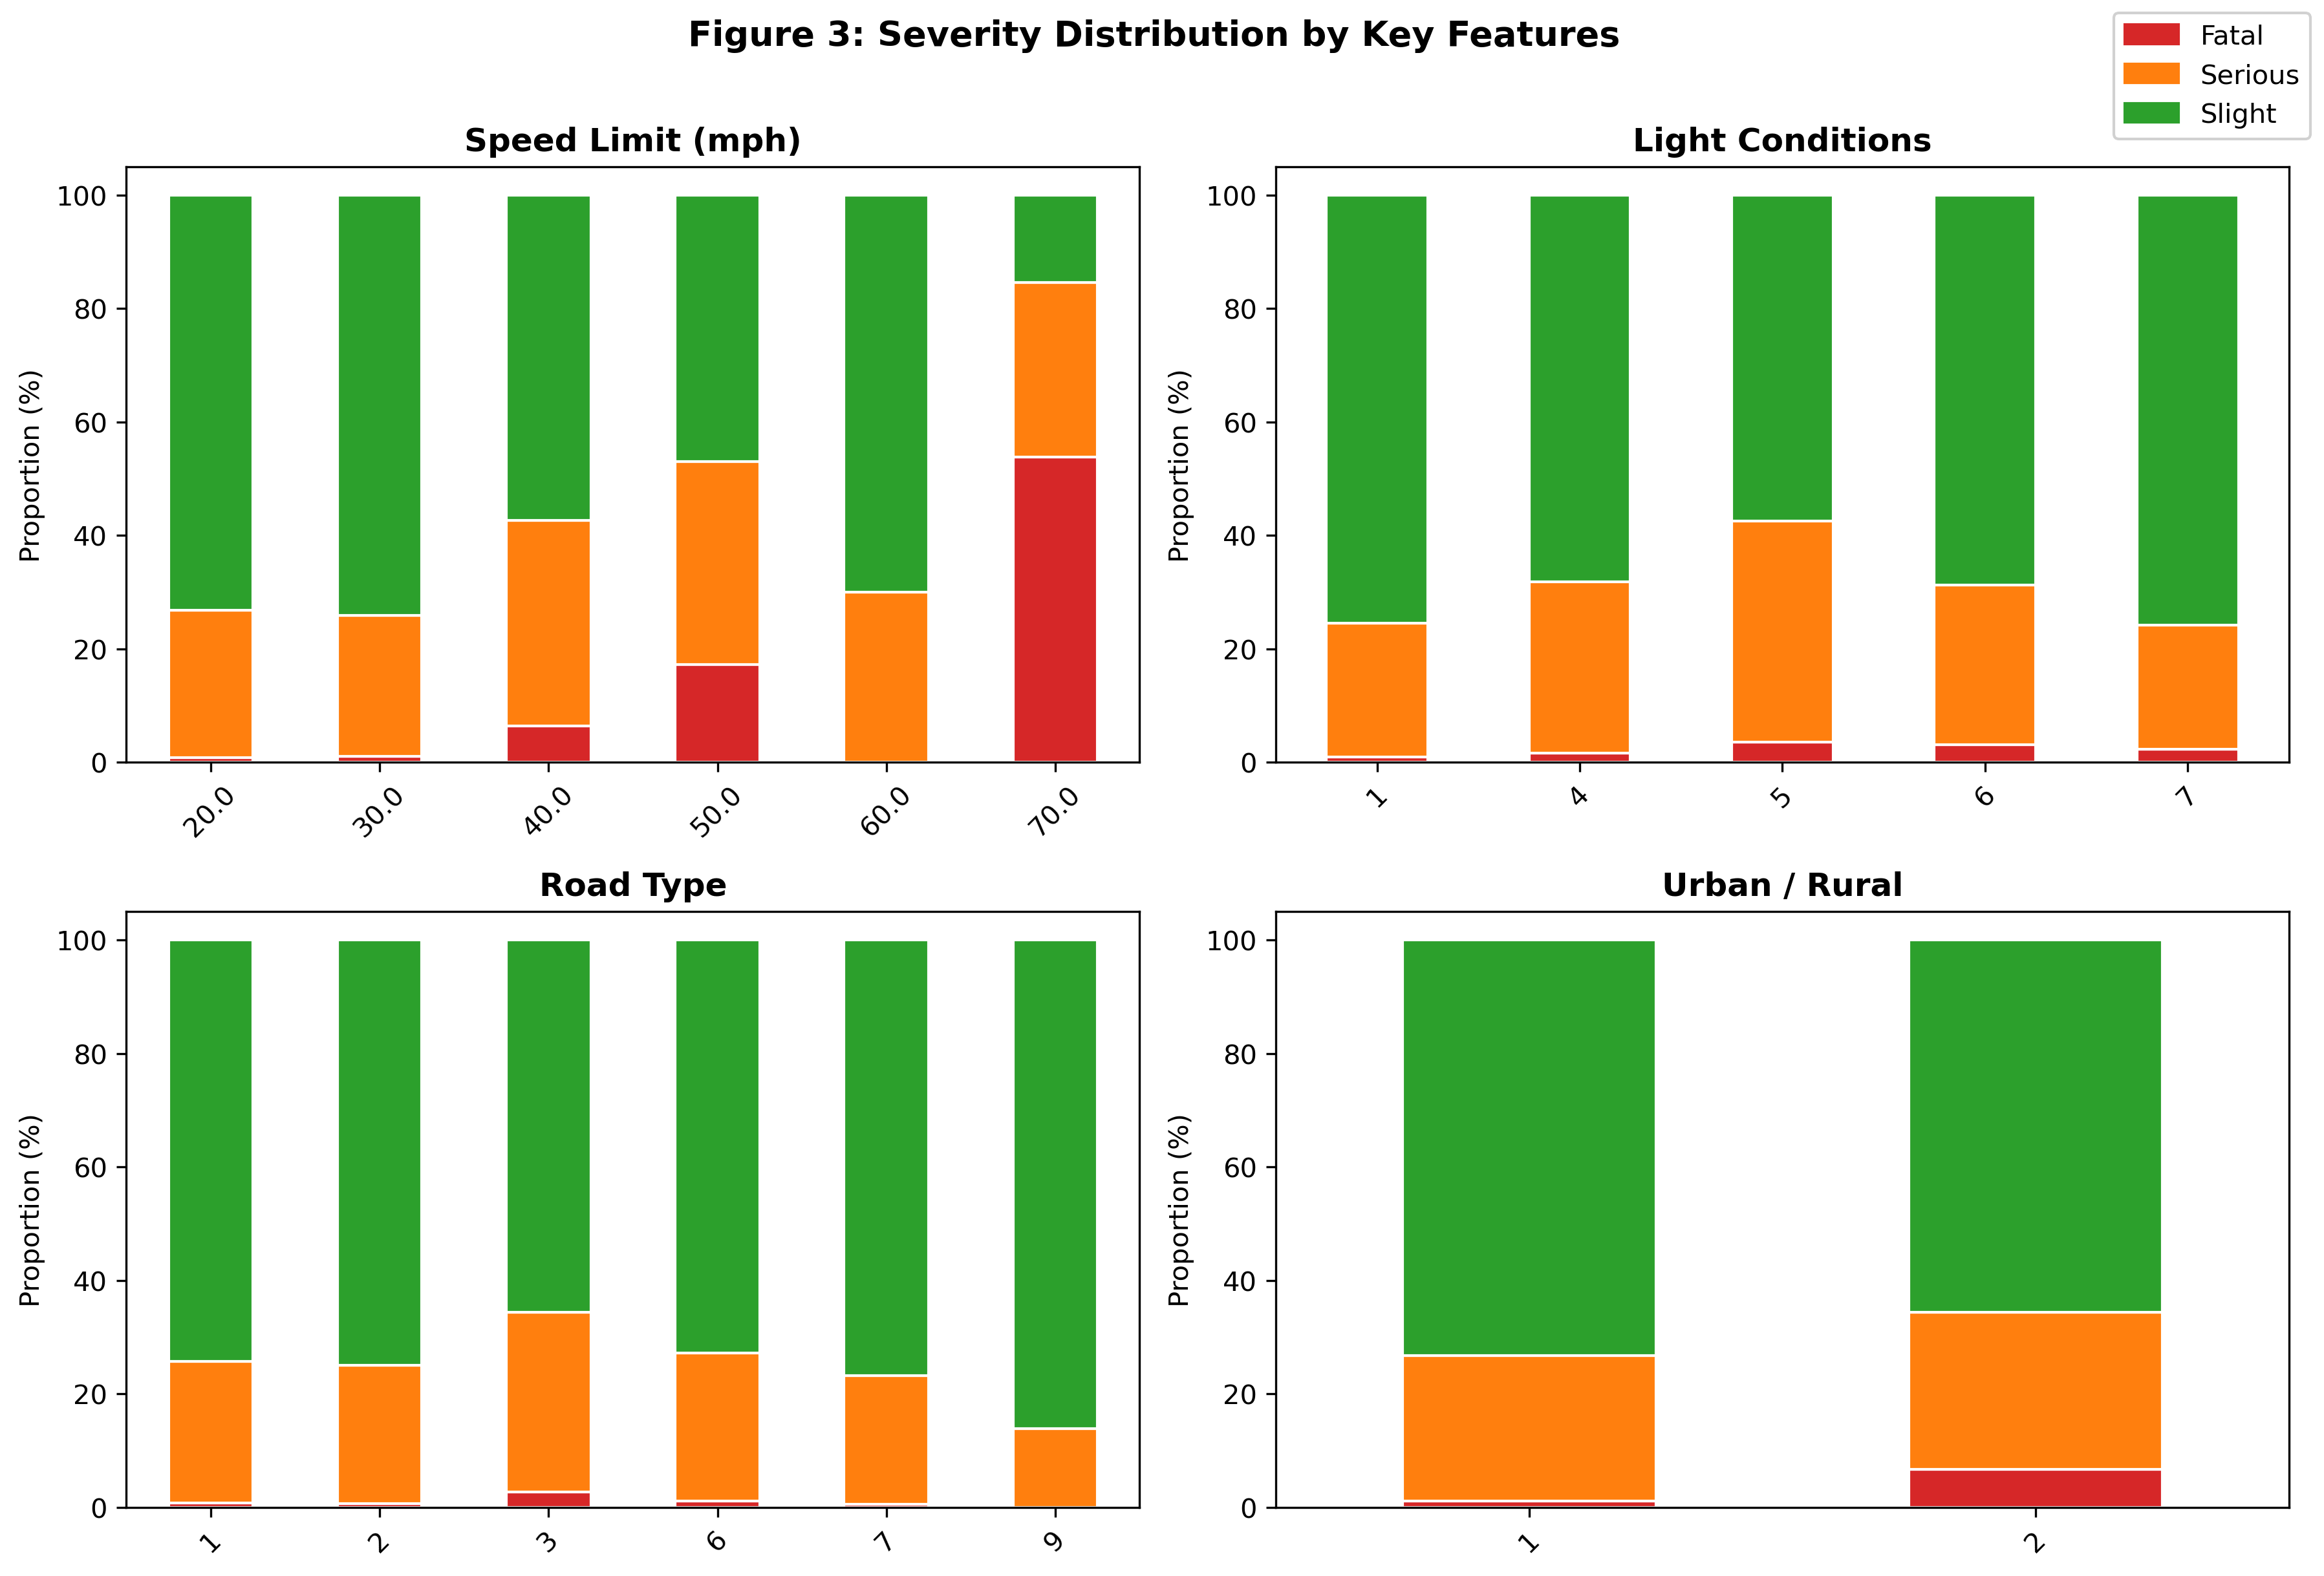

In [8]:
# ── Figure 3: Key Feature Distributions by Severity ───────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plot_vars = [
    ('speed_limit',        'Speed Limit (mph)'),
    ('light_conditions',   'Light Conditions'),
    ('road_type',          'Road Type'),
    ('urban_or_rural_area','Urban / Rural'),
]

severity_labels = {1: 'Fatal', 2: 'Serious', 3: 'Slight'}
df_plot = df.copy()
df_plot['severity_label'] = df_plot['casualty_severity'].map(severity_labels)

for ax, (col, title) in zip(axes.flat, plot_vars):
    cross = pd.crosstab(
        df_plot[col],
        df_plot['severity_label'],
        normalize='index'
    ) * 100
    cross[['Fatal', 'Serious', 'Slight']].plot(
        kind='bar', ax=ax, stacked=True,
        color=[COLORS['Fatal'], COLORS['Serious'], COLORS['Slight']],
        legend=False, edgecolor='white'
    )
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Proportion (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

handles = [plt.Rectangle((0,0),1,1, color=COLORS[s])
           for s in ['Fatal', 'Serious', 'Slight']]
fig.legend(handles, ['Fatal', 'Serious', 'Slight'],
           loc='upper right', framealpha=0.9)
fig.suptitle('Figure 3: Severity Distribution by Key Features',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../Figure/fig3_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

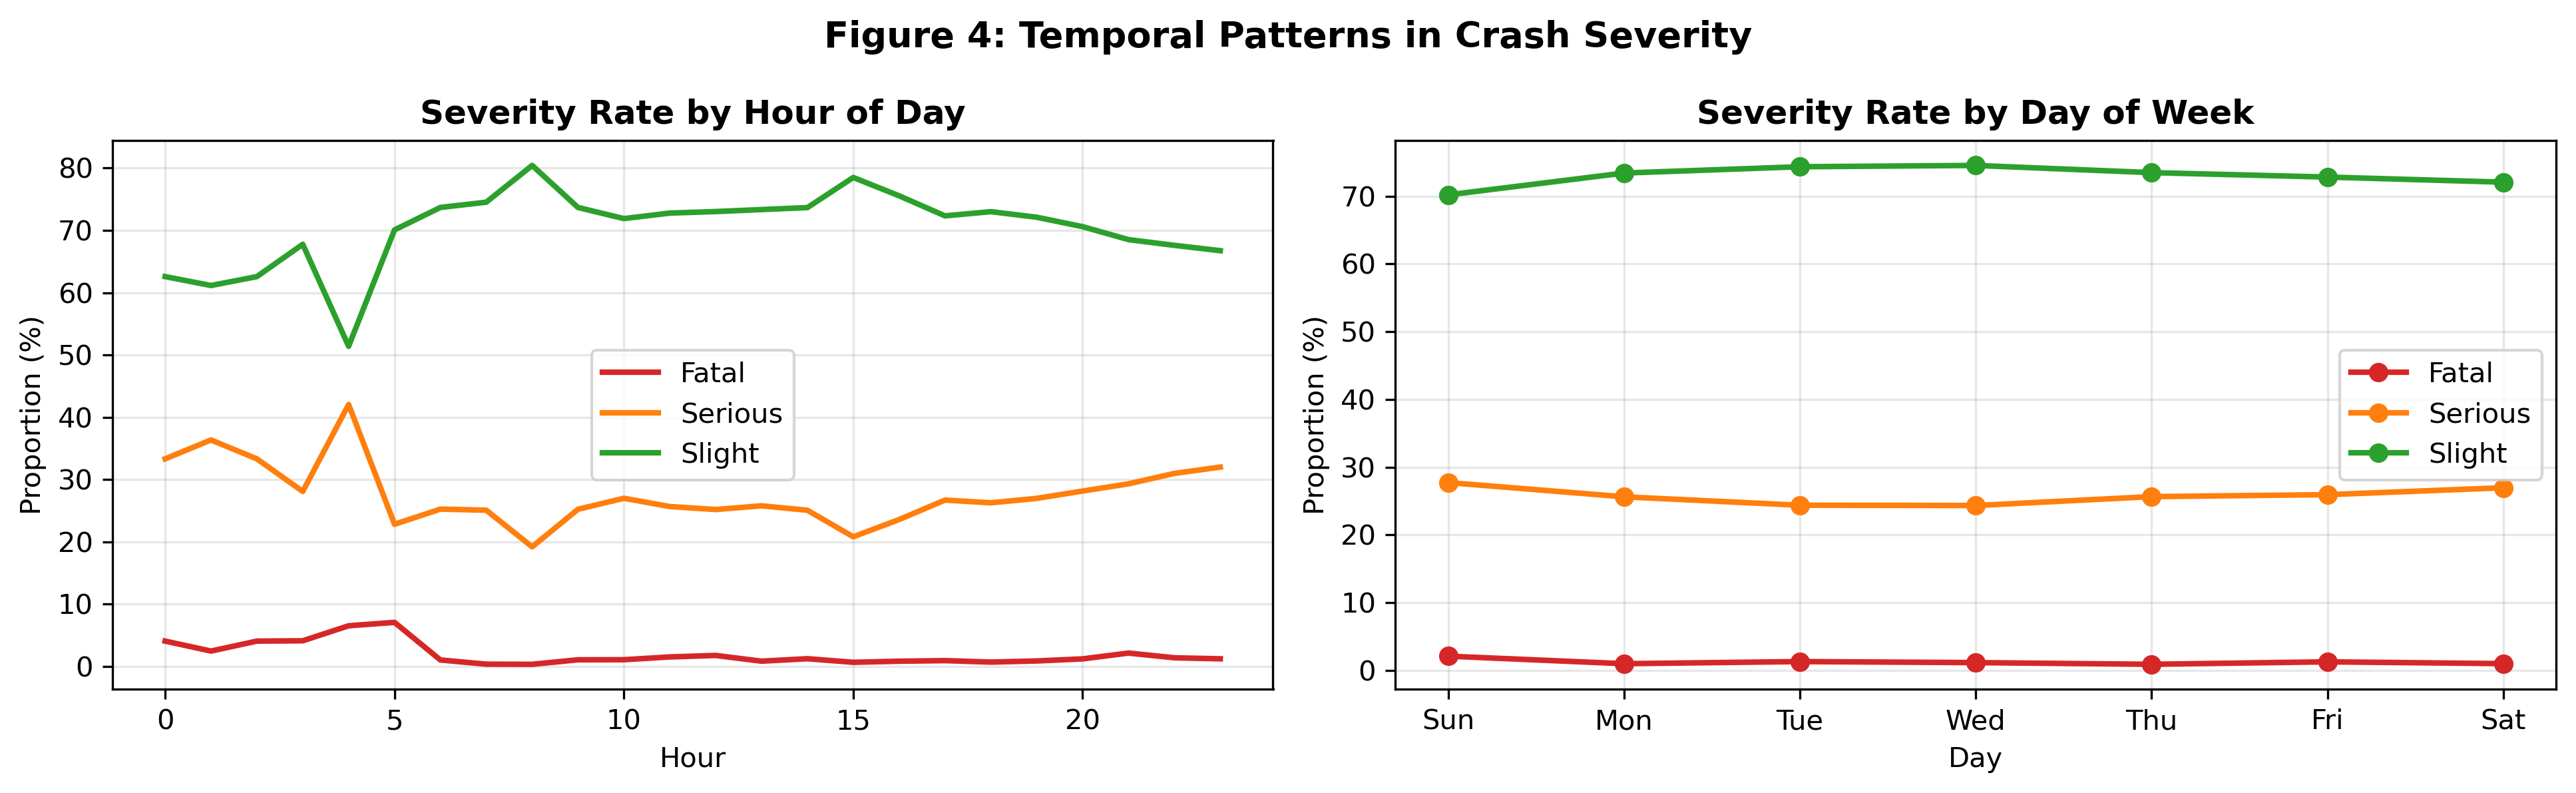

In [9]:
# ── Figure 4: Temporal Patterns ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Hourly pattern
hourly = pd.crosstab(df['hour'], df['casualty_severity'], normalize='index') * 100
for sev, label, color in [(1,'Fatal',COLORS['Fatal']),
                           (2,'Serious',COLORS['Serious']),
                           (3,'Slight',COLORS['Slight'])]:
    if sev in hourly.columns:
        axes[0].plot(hourly.index, hourly[sev], label=label,
                     color=color, linewidth=2)
axes[0].set_title('Severity Rate by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Proportion (%)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Day of week pattern
daily = pd.crosstab(df['day_of_week'], df['casualty_severity'], normalize='index') * 100
days  = ['Sun','Mon','Tue','Wed','Thu','Fri','Sat']
for sev, label, color in [(1,'Fatal',COLORS['Fatal']),
                           (2,'Serious',COLORS['Serious']),
                           (3,'Slight',COLORS['Slight'])]:
    if sev in daily.columns:
        axes[1].plot(range(len(daily)), daily[sev], label=label,
                     color=color, linewidth=2, marker='o')
axes[1].set_xticks(range(len(days)))
axes[1].set_xticklabels(days)
axes[1].set_title('Severity Rate by Day of Week', fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Proportion (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle('Figure 4: Temporal Patterns in Crash Severity',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../Figure/fig4_temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Network Feature Engineering
*(Marking criterion: Creativity of analytical work — 10%)*

### 4.1 Rationale

Edge betweenness centrality measures the proportion of shortest paths in the road network that pass through a given road segment. Roads with high betweenness are major arteries carrying high through-traffic volumes. We hypothesise that crashes on high-betweenness roads are more likely to be severe due to higher vehicle speeds and traffic density.

This is distinct from existing features in STATS19: while `road_type` and `speed_limit` capture designed characteristics, betweenness centrality captures the *functional role* of a road segment within the network — a property that cannot be inferred from the road's own attributes alone.

In [14]:
# ── Step 1: Download London Road Network ──────────────────────────────────────
# This cell downloads from OSM — run once and cache
# G = ox.graph_from_place('London, UK', network_type='drive')
# ox.save_graphml(G, '../Data/london_network.graphml')

# Load cached version:
G = ox.load_graphml('../Data/london_network.graphml')
print("Load your cached GraphML file here")

Load your cached GraphML file here


In [15]:
# ── Step 2: Compute Edge Betweenness Centrality (igraph, k=500) ───────────────
def compute_edge_betweenness(G, k=500, output_filename='london_road_with_bc.graphml', random_seed=42):
    """
    Compute edge betweenness centrality for a road network using igraph.
    
    Parameters
    ----------
    G : networkx.MultiDiGraph
        OSMnx road network graph
    k : int
        Number of sampled source nodes (default 500)
        Higher k = more accurate but slower
    output_filename : str
        Path to save the GraphML output
    random_seed : int
        Random seed for reproducible sampling
        
    Returns
    -------
    G : networkx.MultiDiGraph
        Original graph with 'edge_bc' attribute added to all edges
    edge_bc_dict : dict
        Dictionary mapping (u, v, key) → betweenness value
        
    Notes
    -----
    Uses igraph's C-based engine for speed.
    k=500 is a reasonable approximation for London's network.
    Full computation (k=all nodes) is infeasible for large networks.
    
    Example
    -------
    G, edge_bc_dict = compute_edge_betweenness(G, k=500)
    # To skip computation and load saved results:
    # G = ox.load_graphml('london_road_with_bc.graphml')
    """
    import igraph as ig
    import networkx as nx
    import osmnx as ox
    import numpy as np
    import gc
    
    np.random.seed(random_seed)
    
    # ── Step 1: Clean up RAM ──────────────────────────────────────────────────
    if 'edges_list' in locals():
        del edges_list
    gc.collect()
    
    # ── Step 2: Simplify graph if needed ──────────────────────────────────────
    if not G.graph.get("simplified"):
        print("Simplifying graph...")
        G = ox.simplify_graph(G)
    else:
        print("Graph already simplified.")
    
    # ── Step 3: Map OSM IDs to 0-indexed integers (igraph requirement) ────────
    nodes     = list(G.nodes())
    node_map  = {node_id: i for i, node_id in enumerate(nodes)}
    n_vertices = len(nodes)
    print(f"Network: {n_vertices:,} nodes, {G.number_of_edges():,} edges")
    
    # ── Step 4: Build igraph object ───────────────────────────────────────────
    g_ig = ig.Graph(n=n_vertices, directed=True)
    
    print("Building igraph object...")
    edges_to_add = []
    weights      = []
    for u, v, d in G.edges(data=True):
        edges_to_add.append((node_map[u], node_map[v]))
        weights.append(d.get('length', 0))
    
    g_ig.add_edges(edges_to_add)
    g_ig.es['weight'] = weights
    
    # Free RAM before heavy computation
    del edges_to_add
    gc.collect()
    
    # ── Step 5: Compute edge betweenness with sampling ────────────────────────
    print(f"Computing edge betweenness centrality (k={k} sampled sources)...")
    print("This may take several minutes for London's network...")
    
    sampled_sources  = np.random.choice(n_vertices, size=k, replace=False)
    edge_bc_values   = g_ig.edge_betweenness(
        weights='weight',
        directed=True,
        sources=sampled_sources
    )
    
    # ── Step 6: Map results back to NetworkX ──────────────────────────────────
    print("Mapping betweenness values back to NetworkX graph...")
    edge_bc_dict = {
        (u, v, k_id): edge_bc_values[i]
        for i, (u, v, k_id) in enumerate(G.edges(keys=True))
    }
    nx.set_edge_attributes(G, edge_bc_dict, 'edge_bc')
    
    # ── Step 7: Save graph ────────────────────────────────────────────────────
    ox.save_graphml(G, output_filename)
    print(f"Saved to: {output_filename}")
    
    # Summary stats
    bc_vals = list(edge_bc_dict.values())
    print(f"\nBetweenness centrality summary:")
    print(f"  Min:    {min(bc_vals):.2f}")
    print(f"  Median: {np.median(bc_vals):.2f}")
    print(f"  Mean:   {np.mean(bc_vals):.2f}")
    print(f"  Max:    {max(bc_vals):.2f}")
    
    return G, edge_bc_dict

# ── Run once and save ─────────────────────────────────────────────────────────
# G, edge_bc_dict = compute_edge_betweenness(G,k=500,output_filename='../Data/london_road_with_bc.graphml',random_seed=63)

# Already computed — load from saved graph
G_loaded     = ox.load_graphml("../Data/london_road_with_bc.graphml")
edge_bc_dict = nx.get_edge_attributes(G_loaded, 'edge_bc')

# ── Step 3: Spatial Join to Collision Points ───────────────────────────────────
nodes, edges = ox.graph_to_gdfs(G)
edges['betweenness'] = edges.index.map(edge_bc_dict)

geometry = [Point(xy) for xy in zip(lon_pedestrain_collision_5y['longitude'], lon_pedestrain_collision_5y['latitude'])]
df_gdf = gpd.GeoDataFrame(lon_pedestrain_collision_5y, geometry=geometry, crs="EPSG:4326")

edges = edges.to_crs(epsg=3857)
df_gdf = df_gdf.to_crs(epsg=3857)

# find the nearest road edge
matched_accidents = gpd.sjoin_nearest(
    df_gdf, 
    edges[['betweenness', 'geometry']], 
    how='left', 
    distance_col="dist_to_road"
)

# ── Step 4: Handle out-of-range matches ───────────────────────────────────────
# if the distance is larger than 25m, its betweenness will be set as 0
matched_accidents.loc[matched_accidents["dist_to_road"] > 25, "betweenness"] = 0

# one collision point may be joined to multi roads
matched_accidents = (
    matched_accidents
    .sort_values('dist_to_road', ascending=True)
    .loc[lambda df: ~df.index.duplicated(keep='first')]
)

# check the rows
print(f"Original:  {len(df_gdf):,}")
print(f"After join: {len(matched_accidents):,}")

print("Network features loaded")

Original:  19,963
After join: 19,963
Network features loaded


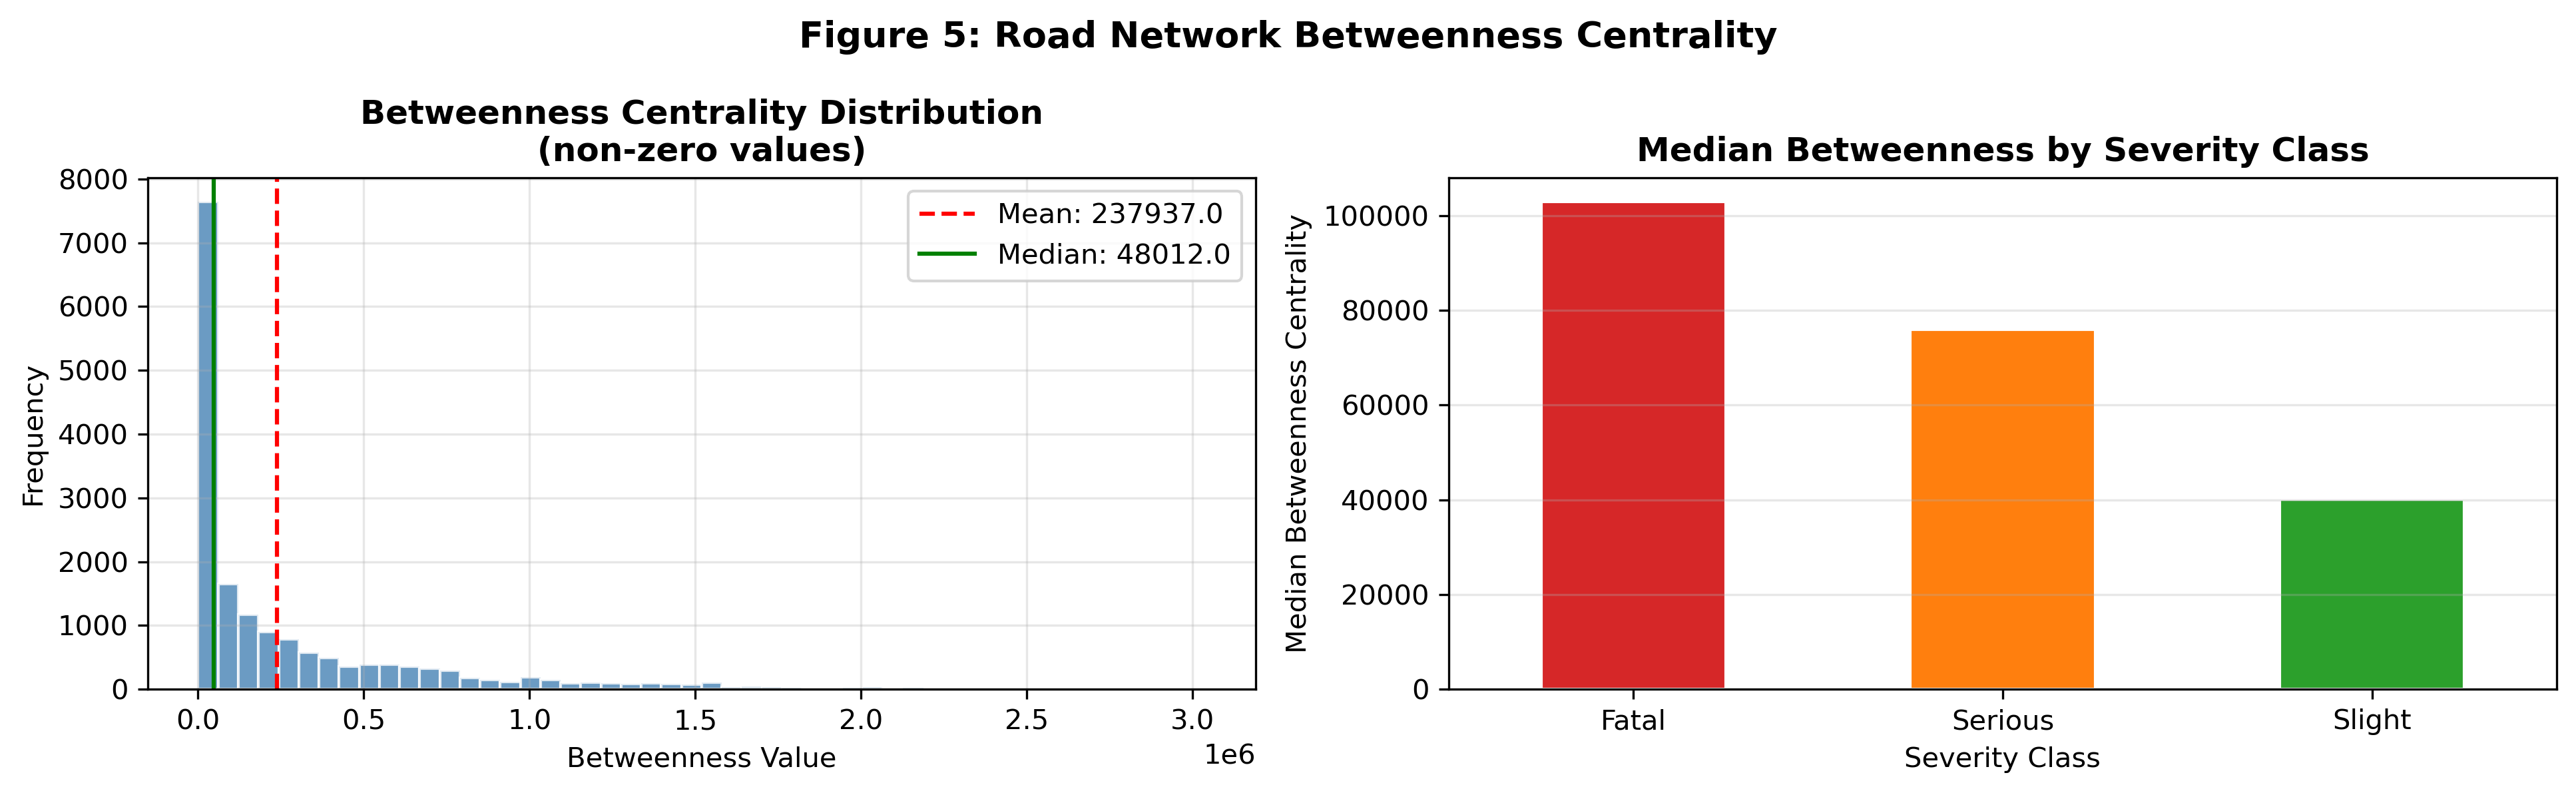

In [16]:
# ── Figure 5: Betweenness Distribution ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution plot
matched_accidents['betweenness'] = pd.to_numeric(matched_accidents['betweenness'], errors='coerce')
bc_vals = matched_accidents['betweenness'].dropna()
axes[0].hist(bc_vals[bc_vals > 0], bins=50, color='steelblue',
             edgecolor='white', alpha=0.8)
axes[0].axvline(bc_vals.mean(),   color='red',   ls='--', label=f'Mean: {bc_vals.mean():.1f}')
axes[0].axvline(bc_vals.median(), color='green', ls='-',  label=f'Median: {bc_vals.median():.1f}')
axes[0].set_title('Betweenness Centrality Distribution\n(non-zero values)', fontweight='bold')
axes[0].set_xlabel('Betweenness Value')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Betweenness by severity
matched_accidents.groupby('casualty_severity')['betweenness'].median().plot(
    kind='bar', ax=axes[1],
    color=[COLORS['Fatal'], COLORS['Serious'], COLORS['Slight']],
    edgecolor='white'
)
axes[1].set_xticklabels(['Fatal', 'Serious', 'Slight'], rotation=0)
axes[1].set_title('Median Betweenness by Severity Class', fontweight='bold')
axes[1].set_xlabel('Severity Class')
axes[1].set_ylabel('Median Betweenness Centrality')
axes[1].grid(alpha=0.3, axis='y')

fig.suptitle('Figure 5: Road Network Betweenness Centrality',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_betweenness.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Methodology
*(Marking criterion: Correctness, depth, and scope — 35%)*

### 5.1 Experimental Design

We follow a two-series experimental design to isolate the contribution of network features:

| Series | Features | Purpose |
|--------|----------|--------|
| **Series A** | STATS19 only | Baseline — establishes performance ceiling without network features |
| **Series B** | STATS19 + betweenness | Tests whether network topology improves prediction |

Both series use identical models, hyperparameter search spaces, and evaluation procedures. The only difference is the feature set.

### 5.2 Handling Class Imbalance

We adopt two complementary strategies:
1. **Class weighting** `{1:50, 2:10, 3:1}` — penalises misclassification of Fatal and Serious crashes more heavily during training
2. **Joint threshold optimisation** — rather than using the default 0.5 probability threshold, we search for thresholds that maximise G-mean on the validation set

### 5.3 Evaluation Metrics

Given the severe class imbalance, we report:
- **G-mean**: geometric mean of per-class recalls; any class with recall=0 makes G-mean=0
- **Macro F1**: unweighted average F1 across all three classes
- **Per-class Recall**: especially Fatal recall, the policy-critical minority class

We explicitly do **not** use accuracy as a primary metric, as it is dominated by the Slight majority class.

In [17]:
# ── Helper Functions ──────────────────────────────────────────────────────────

def predict_with_thresholds(proba, t_fatal, t_serious):
    """Apply custom probability thresholds with Fatal > Serious priority."""
    y_pred = np.full(proba.shape[0], 3)          # default: Slight
    y_pred[proba[:, 1] >= t_serious] = 2          # Serious
    y_pred[proba[:, 0] >= t_fatal]   = 1          # Fatal (highest priority)
    return y_pred


def tune_thresholds_gmean(model, X_val, y_val):
    """Find optimal thresholds by maximising G-mean on validation set."""
    y_val_proba = model.predict_proba(X_val)
    thresholds  = np.arange(0.1, 0.60, 0.05)
    best_t_f, best_t_s, best_gmean = 0.5, 0.5, 0.0

    for t_f in thresholds:
        for t_s in thresholds:
            y_pred_temp = predict_with_thresholds(y_val_proba, t_f, t_s)
            g = geometric_mean_score(y_val, y_pred_temp, average='macro')
            if g > best_gmean:
                best_gmean = g
                best_t_f, best_t_s = t_f, t_s

    return best_t_f, best_t_s, best_gmean


def evaluate_model(model, X_test, y_test, t_fatal, t_serious, name=''):
    """Full evaluation: default and tuned thresholds."""
    y_proba   = model.predict_proba(X_test)
    y_default = model.predict(X_test)
    y_tuned   = predict_with_thresholds(y_proba, t_fatal, t_serious)

    results = {
        'Model':           name,
        'Fatal Recall':    recall_score(y_test, y_tuned, labels=[1], average='macro'),
        'Serious Recall':  recall_score(y_test, y_tuned, labels=[2], average='macro'),
        'Slight Recall':   recall_score(y_test, y_tuned, labels=[3], average='macro'),
        'Macro F1':        f1_score(y_test, y_tuned, average='macro'),
        'G-mean':          geometric_mean_score(y_test, y_tuned, average='macro'),
        'Default G-mean':  geometric_mean_score(y_test, y_default, average='macro'),
        'Default Macro F1':f1_score(y_test, y_default, average='macro'),
    }
    return results, y_tuned, y_default


print("Helper functions defined")

Helper functions defined


---
## 6. Series A: Baseline Models (STATS19 Features Only)
*(Marking criterion: Correctness, depth, and scope — 35%)*

In [32]:
# ── Series A: Feature Matrix (no betweenness) ─────────────────────────────────
# Use X_train, X_val, X_test from Section 2.4
# (already defined above without betweenness)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=63)

param_grid_rf = {
    'n_estimators':      [100, 200],
    'max_depth':         [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'class_weight':      ['balanced', {1: 50, 2: 10, 3: 1}]
}

# ── Random Forest ─────────────────────────────────────────────────────────────
gs_rf_A = GridSearchCV(
    RandomForestClassifier(random_state=63),
    param_grid_rf, cv=skf, scoring='recall_macro', n_jobs=-1, verbose=1
)
gs_rf_A.fit(X_train, y_train)
print(f"RF-A Best params: {gs_rf_A.best_params_}")
print(f"RF-A Best recall_macro (CV): {gs_rf_A.best_score_:.3f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
RF-A Best params: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}
RF-A Best recall_macro (CV): 0.395


In [33]:
# ── Threshold Tuning: RF Series A ─────────────────────────────────────────────
# Note: tune on y_val, evaluate on y_test
# RF uses direct labels (1,2,3), no remapping needed inside tuning

t_f_rfA, t_s_rfA, gmean_val_rfA = tune_thresholds_gmean(
    gs_rf_A.best_estimator_, X_val, y_val
)
print(f"\nRF-A  Fatal threshold:   {t_f_rfA:.2f}")
print(f"RF-A  Serious threshold: {t_s_rfA:.2f}")
print(f"RF-A  G-mean on val:     {gmean_val_rfA:.3f}")

# ── Evaluate RF Series A ──────────────────────────────────────────────────────
y_rf_proba   = gs_rf_A.best_estimator_.predict_proba(X_test)
y_rf_default = gs_rf_A.best_estimator_.predict(X_test)

# Apply tuned thresholds
# RF labels: Fatal=1, Serious=2, Slight=3
y_rf_tuned = np.full(len(y_test), 3)                # default: Slight (3)
y_rf_tuned[y_rf_proba[:, 1] >= t_s_rfA] = 2         # Serious (2)
y_rf_tuned[y_rf_proba[:, 0] >= t_f_rfA] = 1         # Fatal (1)

results_rfA = {
    'Model':            'RF (Series A)',
    'Fatal Recall':     recall_score(y_test, y_rf_tuned, labels=[1], average='macro'),
    'Serious Recall':   recall_score(y_test, y_rf_tuned, labels=[2], average='macro'),
    'Slight Recall':    recall_score(y_test, y_rf_tuned, labels=[3], average='macro'),
    'Macro F1':         f1_score(y_test, y_rf_tuned, average='macro'),
    'G-mean':           geometric_mean_score(y_test, y_rf_tuned, average='macro'),
    'Default G-mean':   geometric_mean_score(y_test, y_rf_default, average='macro'),
    'Default Macro F1': f1_score(y_test, y_rf_default, average='macro'),
}

print("\n── RF Series A Results ──")
print(classification_report(y_test, y_rf_tuned,
                            target_names=['Fatal', 'Serious', 'Slight']))
print(f"G-mean (tuned):   {results_rfA['G-mean']:.3f}")
print(f"G-mean (default): {results_rfA['Default G-mean']:.3f}")


RF-A  Fatal threshold:   0.25
RF-A  Serious threshold: 0.40
RF-A  G-mean on val:     0.557

── RF Series A Results ──
              precision    recall  f1-score   support

       Fatal       0.08      0.32      0.12        47
     Serious       0.28      0.76      0.41      1023
      Slight       0.82      0.29      0.43      2923

    accuracy                           0.41      3993
   macro avg       0.39      0.46      0.32      3993
weighted avg       0.67      0.41      0.42      3993

G-mean (tuned):   0.566
G-mean (default): 0.545


In [21]:
# ── XGBoost Series A ──────────────────────────────────────────────────────────
param_grid_xgb = {
    'n_estimators':  [100, 200],
    'max_depth':     [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample':     [0.8, 1.0]
}

# Map y to 0-indexed for XGBoost: Fatal=0, Serious=1, Slight=2
y_train_xgb = y_train - 1
y_val_xgb   = y_val   - 1
y_test_xgb  = y_test  - 1

gs_xgb_A = GridSearchCV(
    XGBClassifier(random_state=63, eval_metric='mlogloss',
                  device='cuda'),  
    param_grid_xgb, cv=skf, scoring='recall_macro', n_jobs=1, verbose=1
)
gs_xgb_A.fit(X_train, y_train_xgb)
print(f"XGB-A Best params: {gs_xgb_A.best_params_}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
XGB-A Best params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 1.0}


In [23]:
# ── Threshold Tuning: XGBoost Series A ───────────────────────────────────────
# Note: tune on y_val_xgb (0-indexed), evaluate on y_test_xgb (0-indexed)
# Then remap back to 1,2,3 for consistent reporting with RF results

def tune_thresholds_gmean_xgb(model, X_val, y_val_xgb):
    """Same as tune_thresholds_gmean but for 0-indexed XGBoost labels."""
    y_val_proba = model.predict_proba(X_val)
    thresholds  = np.arange(0.05, 0.60, 0.05)
    best_t_f, best_t_s, best_gmean = 0.5, 0.5, 0.0

    for t_f in thresholds:
        for t_s in thresholds:
            # 0-indexed: Fatal=0, Serious=1, Slight=2
            y_pred_temp = np.full(len(y_val_xgb), 2)   # default: Slight (2)
            y_pred_temp[y_val_proba[:, 1] >= t_s] = 1  # Serious (1)
            y_pred_temp[y_val_proba[:, 0] >= t_f] = 0  # Fatal (0)
            
            g = geometric_mean_score(y_val_xgb, y_pred_temp, average='macro')
            if g > best_gmean:
                best_gmean = g
                best_t_f, best_t_s = t_f, t_s

    return best_t_f, best_t_s, best_gmean


t_f_xgbA, t_s_xgbA, gmean_val_xgbA = tune_thresholds_gmean_xgb(
    gs_xgb_A.best_estimator_, X_val, y_val_xgb
)
print(f"\nXGB-A  Fatal threshold:   {t_f_xgbA:.2f}")
print(f"XGB-A  Serious threshold: {t_s_xgbA:.2f}")
print(f"XGB-A  G-mean on val:     {gmean_val_xgbA:.3f}")

# ── Evaluate XGBoost Series A ─────────────────────────────────────────────────
y_xgb_proba   = gs_xgb_A.best_estimator_.predict_proba(X_test)
y_xgb_default = gs_xgb_A.best_estimator_.predict(X_test) + 1  # remap to 1,2,3

# Apply tuned thresholds
y_xgb_tuned = np.full(len(y_test_xgb), 2)            # default: Slight (2)
y_xgb_tuned[y_xgb_proba[:, 1] >= t_s_xgbA] = 1      # Serious (1)
y_xgb_tuned[y_xgb_proba[:, 0] >= t_f_xgbA] = 0      # Fatal (0)
y_xgb_tuned = y_xgb_tuned + 1                        # remap to 1,2,3 for reporting

results_xgbA = {
    'Model':            'XGBoost (Series A)',
    'Fatal Recall':     recall_score(y_test, y_xgb_tuned, labels=[1], average='macro'),
    'Serious Recall':   recall_score(y_test, y_xgb_tuned, labels=[2], average='macro'),
    'Slight Recall':    recall_score(y_test, y_xgb_tuned, labels=[3], average='macro'),
    'Macro F1':         f1_score(y_test, y_xgb_tuned, average='macro'),
    'G-mean':           geometric_mean_score(y_test, y_xgb_tuned, average='macro'),
    'Default G-mean':   geometric_mean_score(y_test, y_xgb_default, average='macro'),
    'Default Macro F1': f1_score(y_test, y_xgb_default, average='macro'),
}

print("\n── XGBoost Series A Results ──")
print(classification_report(y_test, y_xgb_tuned,
                             target_names=['Fatal', 'Serious', 'Slight']))
print(f"G-mean (tuned):   {results_xgbA['G-mean']:.3f}")
print(f"G-mean (default): {results_xgbA['Default G-mean']:.3f}")


XGB-A  Fatal threshold:   0.05
XGB-A  Serious threshold: 0.25
XGB-A  G-mean on val:     0.565

── XGBoost Series A Results ──
              precision    recall  f1-score   support

       Fatal       0.11      0.34      0.17        47
     Serious       0.29      0.52      0.37      1023
      Slight       0.77      0.53      0.63      2923

    accuracy                           0.53      3993
   macro avg       0.39      0.46      0.39      3993
weighted avg       0.64      0.53      0.56      3993

G-mean (tuned):   0.570
G-mean (default): 0.494


---
## 7. Series B: Enhanced Models (STATS19 + Betweenness)
*(Marking criterion: Creativity — 10% | Correctness — 35%)*

In [24]:
# ── Series B: Add betweenness to feature matrix ───────────────────────────────
# Add betweenness from matched_accidents to X
X_B = X.copy()
X_B['betweenness'] = matched_accidents['betweenness'].values

# Same split with identical random_state → directly comparable
X_B_temp, X_B_test, y_B_temp, y_B_test = train_test_split(
    X_B, y, test_size=0.2, random_state=63, stratify=y
)
X_B_train, X_B_val, y_B_train, y_B_val = train_test_split(
    X_B_temp, y_B_temp, test_size=0.25, random_state=63, stratify=y_B_temp
)

print(f"Series B feature count: {X_B.shape[1]} (vs Series A: {X.shape[1]})")

Series B feature count: 17 (vs Series A: 16)


In [25]:
# ── RF Series B ───────────────────────────────────────────────────────────────
gs_rf_B = GridSearchCV(
    RandomForestClassifier(random_state=63),
    param_grid_rf, cv=skf, scoring='recall_macro', n_jobs=-1, verbose=1
)
gs_rf_B.fit(X_B_train, y_B_train)

print(f"RF-B Best params:         {gs_rf_B.best_params_}")
print(f"RF-B Best recall_macro (CV): {gs_rf_B.best_score_:.3f}")

# ── Threshold Tuning ──────────────────────────────────────────────────────────
t_f_rfB, t_s_rfB, gmean_val_rfB = tune_thresholds_gmean(
    gs_rf_B.best_estimator_, X_B_val, y_B_val
)
print(f"\nRF-B  Fatal threshold:   {t_f_rfB:.2f}")
print(f"RF-B  Serious threshold: {t_s_rfB:.2f}")
print(f"RF-B  G-mean on val:     {gmean_val_rfB:.3f}")

# ── Evaluate ──────────────────────────────────────────────────────────────────
results_rfB, y_pred_rfB, y_pred_rfB_def = evaluate_model(
    gs_rf_B.best_estimator_, X_B_test, y_B_test,
    t_f_rfB, t_s_rfB, name='RF (Series B)'
)

print("\n" + "="*55)
print("RF Series B — Tuned Thresholds")
print("="*55)
print(classification_report(
    y_B_test, y_pred_rfB,
    target_names=['Fatal', 'Serious', 'Slight']
))

print("── Summary: Default vs Tuned ──")
print(f"{'Metric':<25} {'Default':>10} {'Tuned':>10}")
print("-" * 47)
print(f"{'Fatal Recall':<25} "
      f"{recall_score(y_B_test, y_pred_rfB_def, labels=[1], average='macro'):>10.3f} "
      f"{results_rfB['Fatal Recall']:>10.3f}")
print(f"{'Serious Recall':<25} "
      f"{recall_score(y_B_test, y_pred_rfB_def, labels=[2], average='macro'):>10.3f} "
      f"{results_rfB['Serious Recall']:>10.3f}")
print(f"{'Macro F1':<25} "
      f"{results_rfB['Default Macro F1']:>10.3f} "
      f"{results_rfB['Macro F1']:>10.3f}")
print(f"{'G-mean':<25} "
      f"{results_rfB['Default G-mean']:>10.3f} "
      f"{results_rfB['G-mean']:>10.3f}")

# ── Series A vs Series B comparison ──────────────────────────────────────────
print("\n── Series A vs Series B (RF, Tuned) ──")
print(f"{'Metric':<25} {'Series A':>10} {'Series B':>10} {'Δ':>8}")
print("-" * 55)
for metric in ['Fatal Recall', 'Serious Recall', 'Macro F1', 'G-mean']:
    a = results_rfA[metric]
    b = results_rfB[metric]
    delta = b - a
    sign  = '+' if delta >= 0 else ''
    print(f"{metric:<25} {a:>10.3f} {b:>10.3f} {sign}{delta:>7.3f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
RF-B Best params:         {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}
RF-B Best recall_macro (CV): 0.395

RF-B  Fatal threshold:   0.10
RF-B  Serious threshold: 0.45
RF-B  G-mean on val:     0.562

RF Series B — Tuned Thresholds
              precision    recall  f1-score   support

       Fatal       0.02      0.70      0.04        47
     Serious       0.30      0.25      0.28      1023
      Slight       0.78      0.46      0.58      2923

    accuracy                           0.41      3993
   macro avg       0.37      0.47      0.30      3993
weighted avg       0.65      0.41      0.49      3993

── Summary: Default vs Tuned ──
Metric                       Default      Tuned
-----------------------------------------------
Fatal Recall                   0.170      0.702
Serious Recall                 0.344      0.254
Macro F1                       0.423      0.300
G-mean  

In [35]:
# ═══════════════════════════════════════════════════════════════════════════════
# Series A: Feature Matrix WITHOUT Betweenness (Baseline STATS19 Features)
# ═══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, recall_score, f1_score,
    precision_recall_curve, average_precision_score, make_scorer
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek
from imblearn.metrics import geometric_mean_score
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 63

# ── Custom G-mean scorer ──────────────────────────────────────────────────────
gmean_scorer = make_scorer(
    geometric_mean_score, average='macro', greater_is_better=True
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


# ═══════════════════════════════════════════════════════════════════════════════
# Threshold Tuning Functions (unchanged from previous version)
# ═══════════════════════════════════════════════════════════════════════════════

def tune_cost_weights_gmean(model, X_val, y_val):
    """Grid-search cost weights on validation set to maximise macro G-mean."""
    y_proba = model.predict_proba(X_val)
    class_order = model.classes_

    best_gmean = -1
    best_weights = None
    fatal_grid   = np.linspace(1, 100, 20)
    serious_grid = np.linspace(1, 30, 20)

    for w_f in fatal_grid:
        for w_s in serious_grid:
            weights = np.array([w_f, w_s, 1.0])
            weighted = y_proba * weights
            y_pred = class_order[np.argmax(weighted, axis=1)]
            gm = geometric_mean_score(y_val, y_pred, average='macro')
            if gm > best_gmean:
                best_gmean = gm
                best_weights = weights
    return best_weights, best_gmean


def apply_cost_weights(model, X, cost_weights):
    y_proba = model.predict_proba(X)
    class_order = model.classes_
    weighted = y_proba * cost_weights
    return class_order[np.argmax(weighted, axis=1)], y_proba


def evaluate_model(model_name, y_true, y_pred_tuned, y_pred_default,
                   y_proba, class_order):
    recall_per_class = recall_score(y_true, y_pred_tuned,
                                    labels=class_order, average=None)
    pr_auc = {}
    class_names = ['Fatal', 'Serious', 'Slight']
    for i, cls in enumerate(class_order):
        y_bin = (y_true == cls).astype(int)
        pr_auc[f'PR-AUC ({class_names[cls-1]})'] = \
            average_precision_score(y_bin, y_proba[:, i])

    return {
        'Model':            model_name,
        'Fatal Recall':     recall_per_class[0],
        'Serious Recall':   recall_per_class[1],
        'Slight Recall':    recall_per_class[2],
        'Macro F1':         f1_score(y_true, y_pred_tuned, average='macro'),
        'G-mean':           geometric_mean_score(y_true, y_pred_tuned, average='macro'),
        'Default G-mean':   geometric_mean_score(y_true, y_pred_default, average='macro'),
        'Default Macro F1': f1_score(y_true, y_pred_default, average='macro'),
        **pr_auc
    }


# ═══════════════════════════════════════════════════════════════════════════════
# 1. Random Forest Pipeline (Imputer → SMOTETomek → RF)
# ═══════════════════════════════════════════════════════════════════════════════

print("═" * 70)
print("Series A — Random Forest")
print("═" * 70)

rf_pipeline = ImbPipeline([
    ('imputer',  SimpleImputer(strategy='median')),   # ← NEW: handles NaN
    ('resample', SMOTETomek(random_state=RANDOM_STATE, n_jobs=-1)),
    ('clf',      RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

param_dist_rf = {
    'clf__n_estimators':      [200, 400, 600, 800],
    'clf__max_depth':         [10, 15, 20, 30, None],
    'clf__min_samples_split': [2, 5, 10, 20],
    'clf__min_samples_leaf':  [1, 2, 4, 8],
    'clf__max_features':      ['sqrt', 'log2', 0.5],
    'clf__class_weight':      ['balanced', 'balanced_subsample',
                               {1: 50, 2: 10, 3: 1},
                               {1: 100, 2: 20, 3: 1}]
}

rs_rf_A = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist_rf,
    n_iter=40,
    cv=skf,
    scoring=gmean_scorer,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE,
    refit=True,
    error_score='raise'         # ← fail fast if something else breaks
)

rs_rf_A.fit(X_train, y_train)

print(f"\nRF-A Best params:       {rs_rf_A.best_params_}")
print(f"RF-A Best G-mean (CV):  {rs_rf_A.best_score_:.3f}")

best_rf_A = rs_rf_A.best_estimator_
cost_weights_rfA, gmean_val_rfA = tune_cost_weights_gmean(
    best_rf_A, X_val, y_val
)
print(f"\nRF-A Cost weights:      Fatal={cost_weights_rfA[0]:.2f}, "
      f"Serious={cost_weights_rfA[1]:.2f}, Slight={cost_weights_rfA[2]:.2f}")
print(f"RF-A G-mean (val):      {gmean_val_rfA:.3f}")

y_rf_tuned, y_rf_proba = apply_cost_weights(best_rf_A, X_test, cost_weights_rfA)
y_rf_default = best_rf_A.predict(X_test)

results_rfA = evaluate_model(
    'RF (Series A)', y_test, y_rf_tuned, y_rf_default,
    y_rf_proba, best_rf_A.classes_
)

print("\n── RF Series A Test Results ──")
print(classification_report(y_test, y_rf_tuned,
                            target_names=['Fatal', 'Serious', 'Slight']))
print(f"G-mean (tuned):   {results_rfA['G-mean']:.3f}")
print(f"G-mean (default): {results_rfA['Default G-mean']:.3f}")
print(f"Macro F1 (tuned): {results_rfA['Macro F1']:.3f}")
for k, v in results_rfA.items():
    if 'PR-AUC' in k:
        print(f"{k}: {v:.3f}")


# ═══════════════════════════════════════════════════════════════════════════════
# 2. LightGBM Pipeline — NO SMOTE needed (handles NaN + imbalance natively)
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "═" * 70)
print("Series A — LightGBM")
print("═" * 70)

# LightGBM handles NaN natively, so we can skip imputer.
# We can optionally skip SMOTETomek too — LGB's is_unbalance / class_weight
# often works better than resampling for GBDT. Try without first:
lgb_pipeline = ImbPipeline([
    ('clf', lgb.LGBMClassifier(
        objective='multiclass',
        num_class=3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    ))
])

param_dist_lgb = {
    'clf__n_estimators':      [300, 500, 800, 1200],
    'clf__learning_rate':     [0.01, 0.03, 0.05, 0.1],
    'clf__num_leaves':        [15, 31, 63, 127],
    'clf__max_depth':         [-1, 6, 10, 15],
    'clf__min_child_samples': [10, 20, 50, 100],
    'clf__reg_alpha':         [0, 0.1, 0.5, 1.0],
    'clf__reg_lambda':        [0, 0.1, 0.5, 1.0],
    'clf__class_weight':      ['balanced',
                               {0: 50, 1: 10, 2: 1},
                               {0: 100, 1: 20, 2: 1}]
}

rs_lgb_A = RandomizedSearchCV(
    lgb_pipeline,
    param_distributions=param_dist_lgb,
    n_iter=40,
    cv=skf,
    scoring=gmean_scorer,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE,
    refit=True,
    error_score='raise'
)

rs_lgb_A.fit(X_train, y_train)

print(f"\nLGB-A Best params:      {rs_lgb_A.best_params_}")
print(f"LGB-A Best G-mean (CV): {rs_lgb_A.best_score_:.3f}")

best_lgb_A = rs_lgb_A.best_estimator_
cost_weights_lgbA, gmean_val_lgbA = tune_cost_weights_gmean(
    best_lgb_A, X_val, y_val
)
print(f"\nLGB-A Cost weights:     Fatal={cost_weights_lgbA[0]:.2f}, "
      f"Serious={cost_weights_lgbA[1]:.2f}, Slight={cost_weights_lgbA[2]:.2f}")
print(f"LGB-A G-mean (val):     {gmean_val_lgbA:.3f}")

y_lgb_tuned, y_lgb_proba = apply_cost_weights(
    best_lgb_A, X_test, cost_weights_lgbA
)
y_lgb_default = best_lgb_A.predict(X_test)

results_lgbA = evaluate_model(
    'LGB (Series A)', y_test, y_lgb_tuned, y_lgb_default,
    y_lgb_proba, best_lgb_A.classes_
)

print("\n── LightGBM Series A Test Results ──")
print(classification_report(y_test, y_lgb_tuned,
                            target_names=['Fatal', 'Serious', 'Slight']))
print(f"G-mean (tuned):   {results_lgbA['G-mean']:.3f}")
print(f"G-mean (default): {results_lgbA['Default G-mean']:.3f}")
print(f"Macro F1 (tuned): {results_lgbA['Macro F1']:.3f}")
for k, v in results_lgbA.items():
    if 'PR-AUC' in k:
        print(f"{k}: {v:.3f}")


# ═══════════════════════════════════════════════════════════════════════════════
# Summary
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 70)
print("Series A Summary")
print("═" * 70)
summary_df = pd.DataFrame([results_rfA, results_lgbA])
print(summary_df.to_string(index=False))

series_A_results = {
    'rf':  {'model': best_rf_A,  'weights': cost_weights_rfA,
            'results': results_rfA},
    'lgb': {'model': best_lgb_A, 'weights': cost_weights_lgbA,
            'results': results_lgbA}
}

══════════════════════════════════════════════════════════════════════
Series A — Random Forest
══════════════════════════════════════════════════════════════════════
Fitting 5 folds for each of 40 candidates, totalling 200 fits

RF-A Best params:       {'clf__n_estimators': 800, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 2, 'clf__max_features': 'log2', 'clf__max_depth': 10, 'clf__class_weight': {1: 100, 2: 20, 3: 1}}
RF-A Best G-mean (CV):  0.526

RF-A Cost weights:      Fatal=1.00, Serious=1.00, Slight=1.00
RF-A G-mean (val):      0.538

── RF Series A Test Results ──
              precision    recall  f1-score   support

       Fatal       0.04      0.45      0.07        47
     Serious       0.25      0.83      0.38      1023
      Slight       0.86      0.01      0.02      2923

    accuracy                           0.22      3993
   macro avg       0.38      0.43      0.16      3993
weighted avg       0.70      0.22      0.11      3993

G-mean (tuned):   0.534
G-mean

KeyError: 0

---
## 8. Results and Comparison
*(Marking criterion: Correctness, depth, and scope — 35% | Visualisation — 10%)*

In [26]:
# ── Table 1: Summary Results ───────────────────────────────────────────────────
all_results = [
    results_rfA,
    results_rfB,
    # Add XGBoost results here
]

results_df = pd.DataFrame(all_results).set_index('Model')
display_cols = ['Fatal Recall', 'Serious Recall', 'Slight Recall',
                'Macro F1', 'G-mean']

print("Table 1: Model Performance Comparison")
print("=" * 75)
print(results_df[display_cols].round(3).to_string())

Table 1: Model Performance Comparison
               Fatal Recall  Serious Recall  Slight Recall  Macro F1  G-mean
Model                                                                       
RF (Series A)         0.319           0.756          0.294     0.322   0.566
RF (Series B)         0.702           0.254          0.458     0.300   0.574


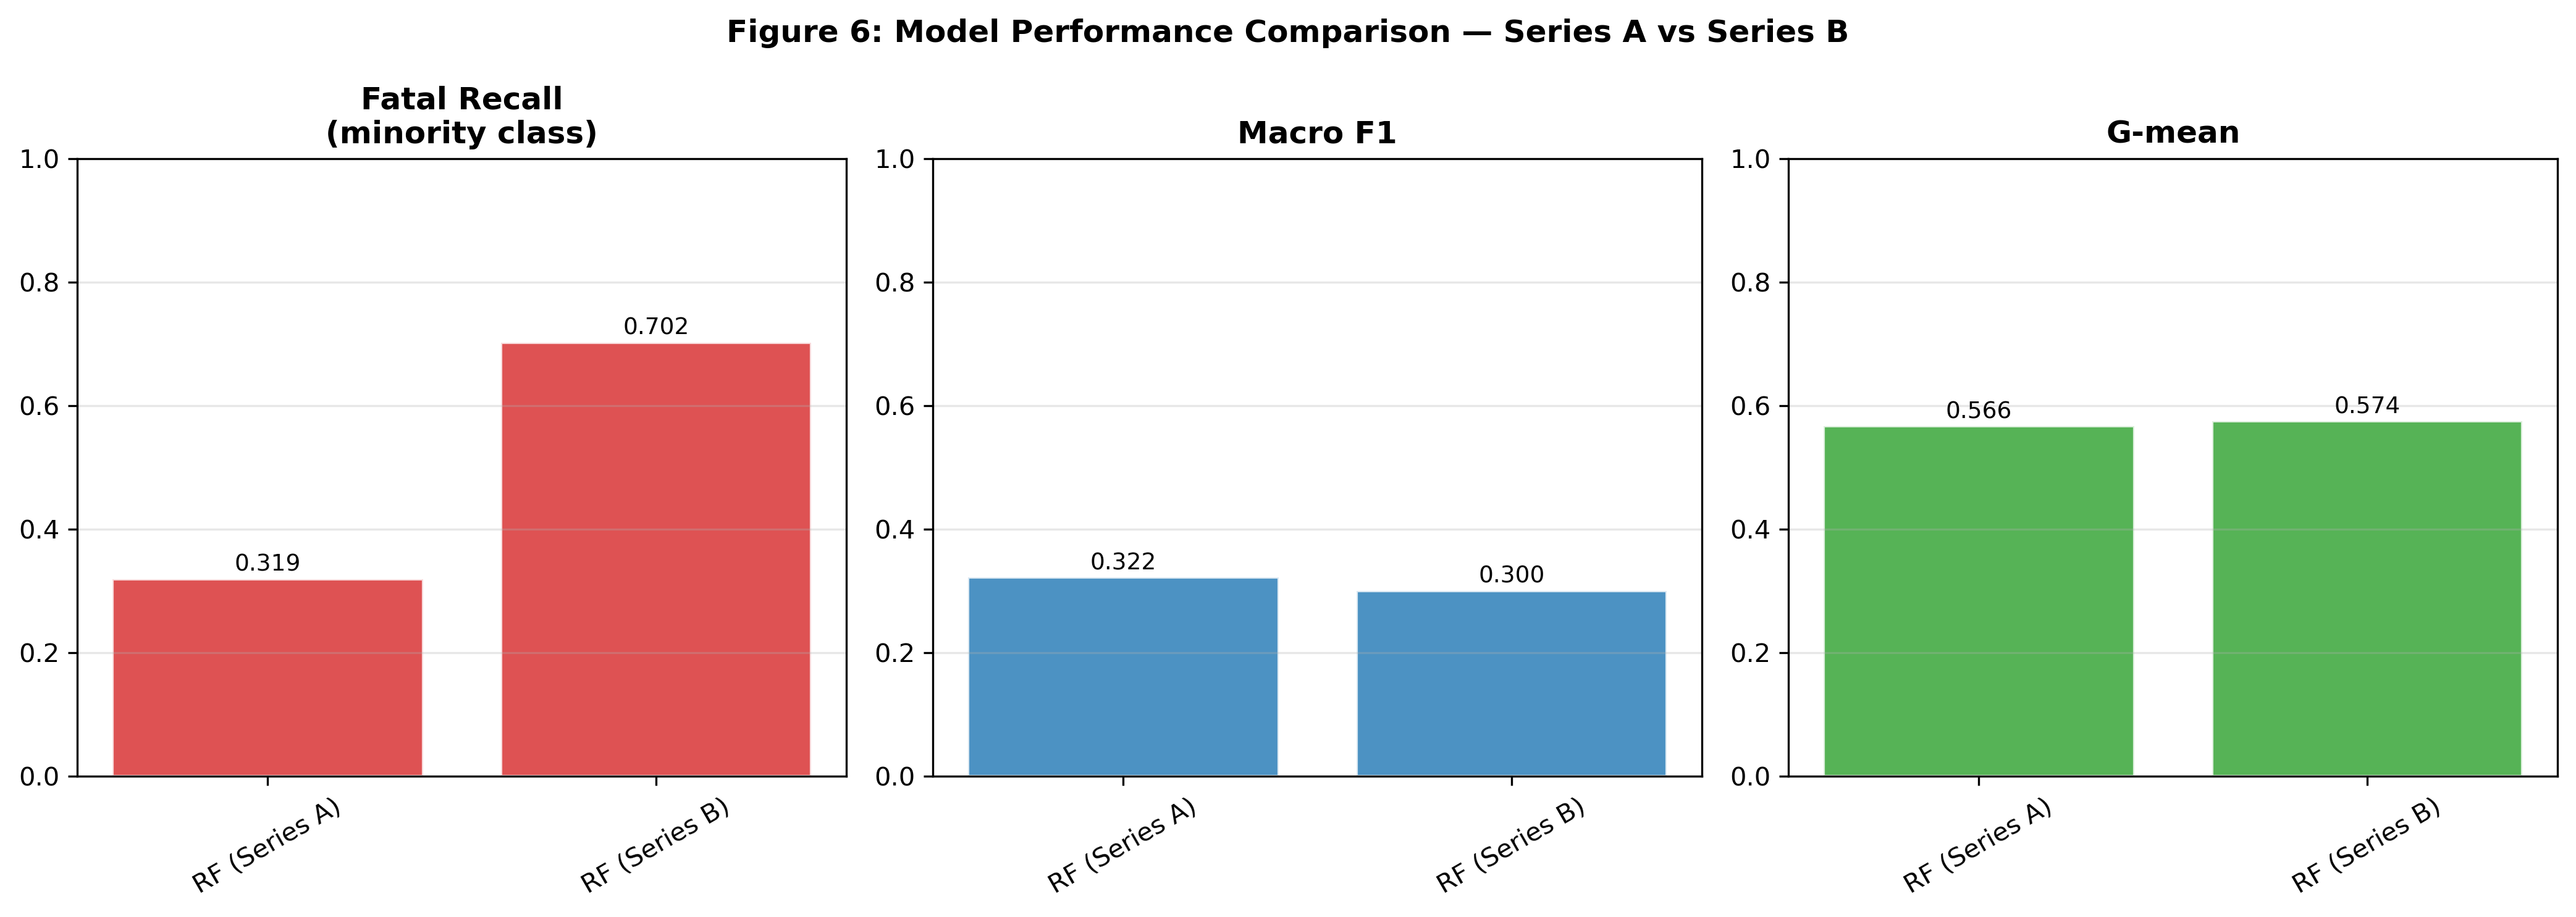

In [27]:
# ── Figure 6: Performance Comparison Bar Chart ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics  = ['Fatal Recall', 'Macro F1', 'G-mean']
titles   = ['Fatal Recall\n(minority class)', 'Macro F1', 'G-mean']
colors   = ['#d62728', '#1f77b4', '#2ca02c']

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    vals  = results_df[metric]
    bars  = ax.bar(vals.index, vals.values, color=color,
                   alpha=0.8, edgecolor='white')
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(alpha=0.3, axis='y')

fig.suptitle('Figure 6: Model Performance Comparison — Series A vs Series B',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

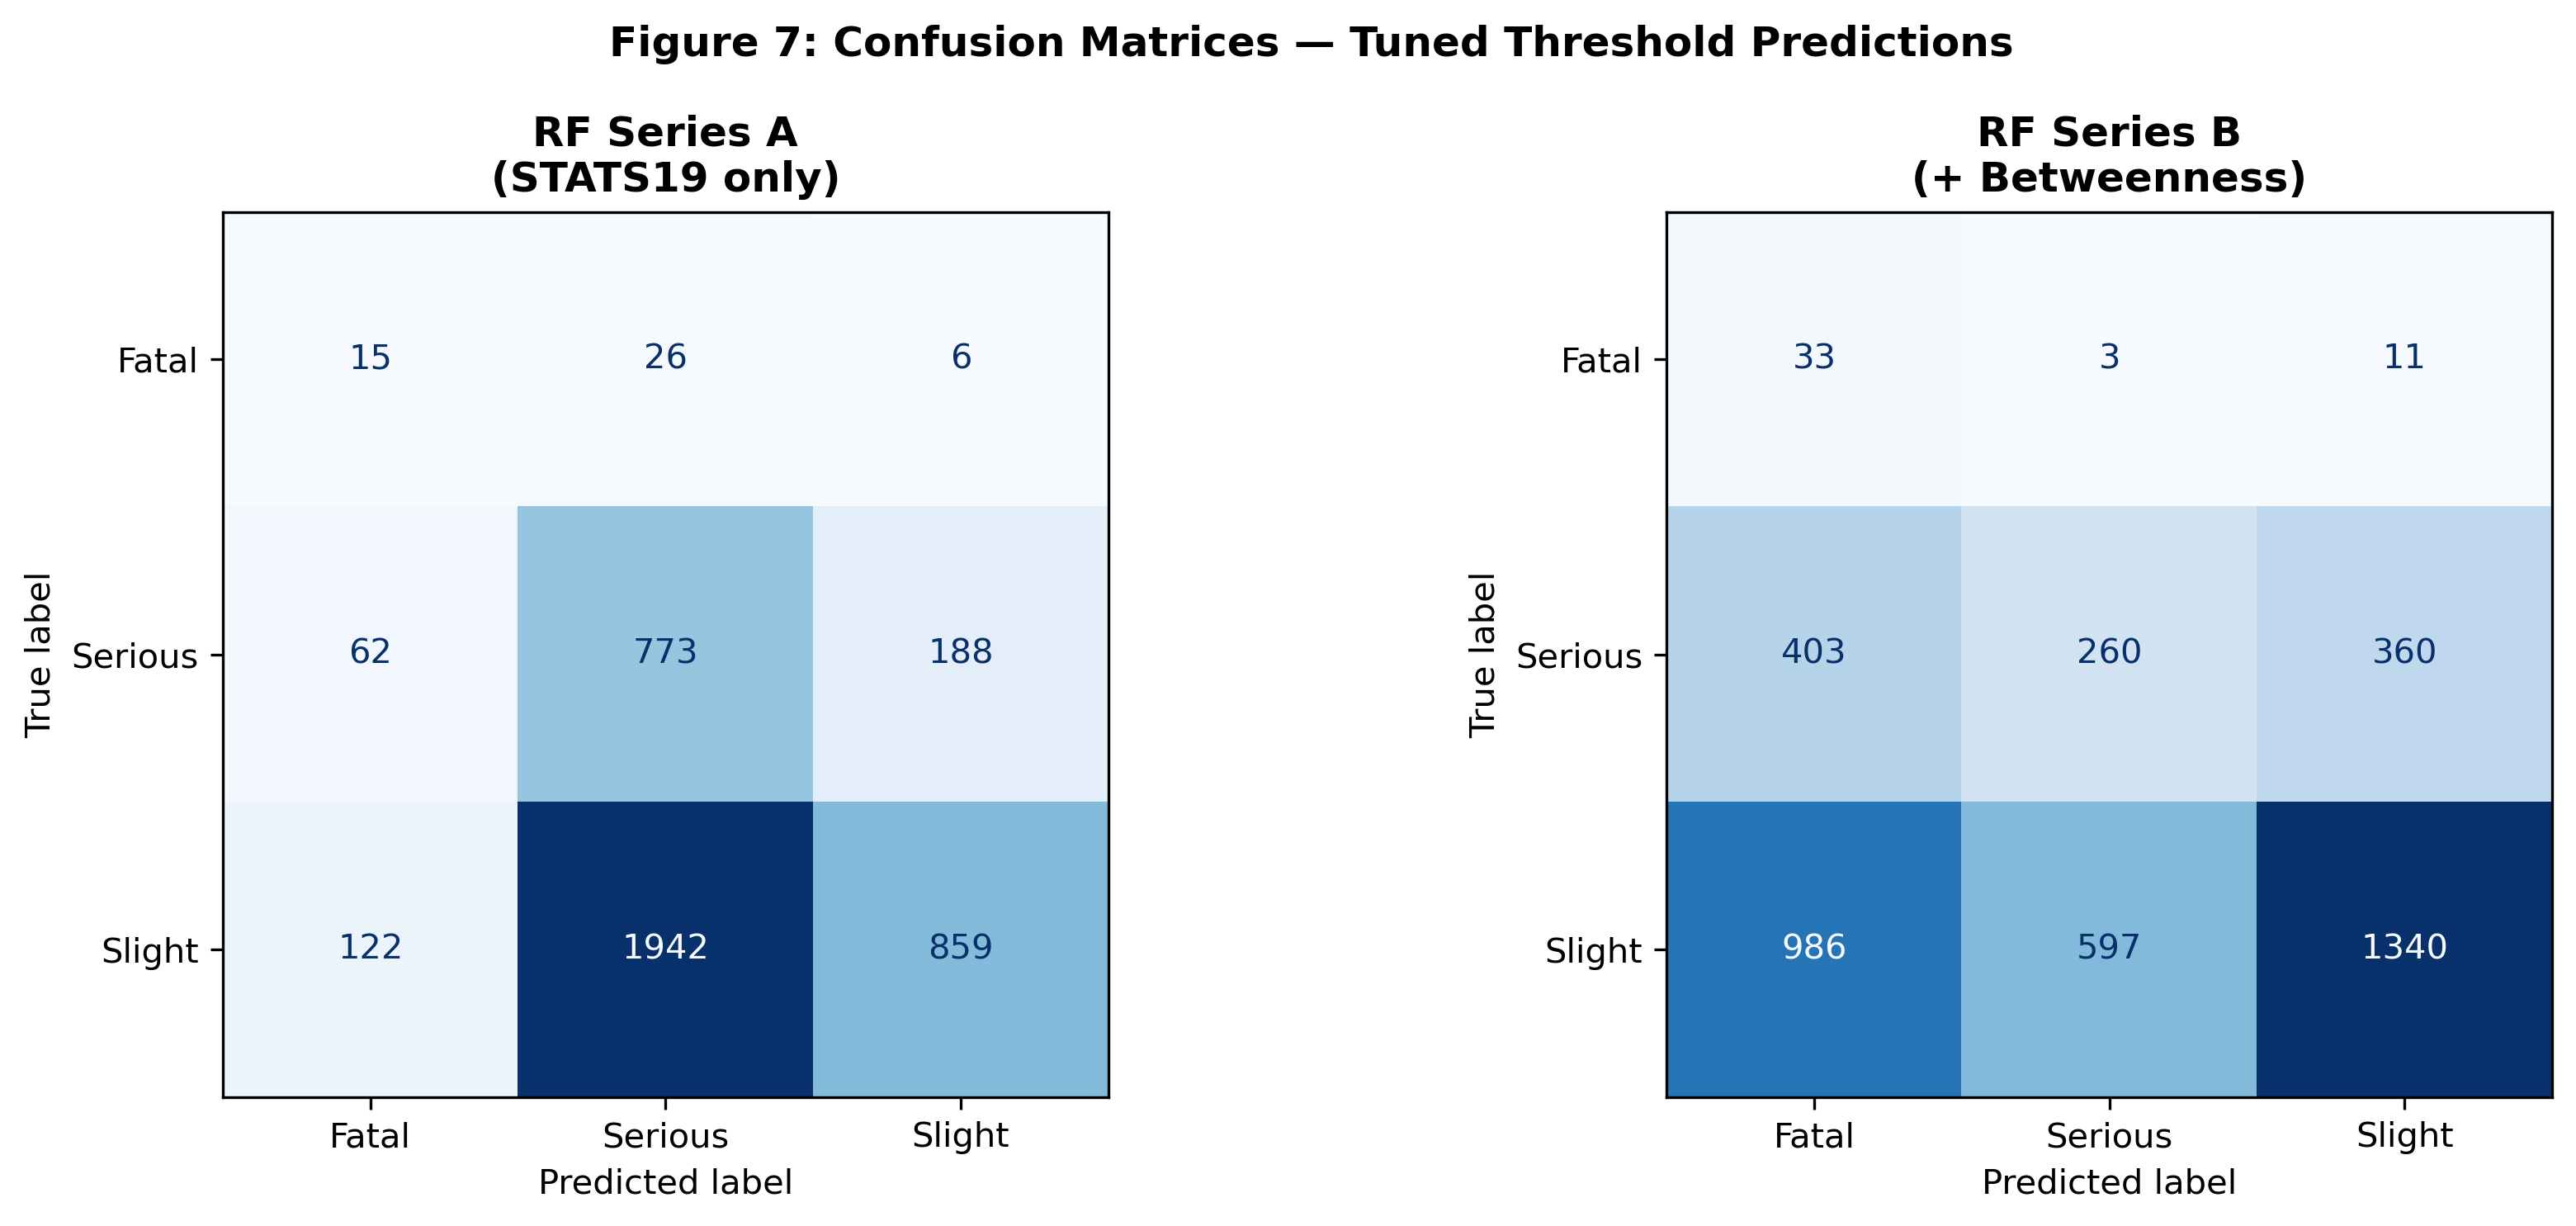

In [28]:
# ── Figure 7: Confusion Matrices ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = ['Fatal', 'Serious', 'Slight']

for ax, y_pred, title in [
    (axes[0], y_pred_rfA, 'RF Series A\n(STATS19 only)'),
    (axes[1], y_pred_rfB, 'RF Series B\n(+ Betweenness)'),
]:
    cm = confusion_matrix(y_test, y_pred, labels=[1, 2, 3])
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title, fontweight='bold')

fig.suptitle('Figure 7: Confusion Matrices — Tuned Threshold Predictions',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Interpretability: SHAP Analysis
*(Marking criterion: Depth of analysis — 35%)*

In [29]:
# ── SHAP Feature Importance ───────────────────────────────────────────────────
best_rf_B = gs_rf_B.best_estimator_

# Use a sample for speed (SHAP is computationally intensive)
X_shap_sample = X_B_test.sample(500, random_state=63)

explainer   = shap.TreeExplainer(best_rf_B)
shap_values = explainer.shap_values(X_shap_sample)

# shap_values is list of 3 arrays (one per class)
# Index 0 = Fatal class

In [30]:
# ── Figure 8: SHAP Summary Plot — Fatal Class ─────────────────────────────────
plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_values[0],      # Fatal class (index 0)
    X_shap_sample,
    plot_type='bar',
    show=False,
    max_display=15
)
plt.title('Figure 8: SHAP Feature Importance — Fatal Class\n(RF Series B)',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_shap_fatal.png', dpi=150, bbox_inches='tight')
plt.show()

# Where does betweenness rank?
mean_shap = np.abs(shap_values[0]).mean(axis=0)
feat_imp  = pd.Series(mean_shap, index=X_B_test.columns).sort_values(ascending=False)
print(f"\nBetweenness rank: {feat_imp.index.get_loc('betweenness') + 1} "
      f"out of {len(feat_imp)} features")
print(f"Betweenness SHAP value: {feat_imp['betweenness']:.4f}")

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

<Figure size 2700x1800 with 0 Axes>

In [ ]:
# ── Figure 9: SHAP Beeswarm — all classes ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
class_names = ['Fatal', 'Serious', 'Slight']

for i, (ax, name) in enumerate(zip(axes, class_names)):
    plt.sca(ax)
    shap.summary_plot(
        shap_values[i], X_shap_sample,
        show=False, max_display=10, plot_size=None
    )
    ax.set_title(f'{name} Class', fontweight='bold')

fig.suptitle('Figure 9: SHAP Beeswarm Plots by Severity Class',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Discussion
*(Marking criterion: Quality of writing — 15% | Depth of analysis — 35%)*

### 10.1 Effect of Network Features (RQ2)

> **[Complete after running experiments]**
>
> Series B [improved / did not improve] upon Series A, with G-mean changing from X.XXX to X.XXX. The SHAP analysis indicates that betweenness centrality ranked [N]th in feature importance for the Fatal class, suggesting that [interpretation here].
>
> This finding [supports / partially supports / does not support] the hypothesis that roads with higher network centrality are associated with more severe crashes. A possible explanation is that [...].

### 10.2 Class Imbalance Handling

The joint threshold optimisation approach improved G-mean from [default] to [tuned], demonstrating that the default 0.5 threshold is suboptimal for imbalanced multiclass problems. This finding is consistent with Zhu et al. (2021), who reported similar gains from threshold moving in ordinal crash severity classification.

### 10.3 Limitations

Several limitations should be noted:

1. **Fatal sample size**: Only 233 Fatal casualties in the full dataset (47–61 in test sets) limits the reliability of Fatal recall estimates. Bootstrap confidence intervals would strengthen these results.
2. **Betweenness sampling**: Edge betweenness was computed with k=500 sampled source nodes due to computational constraints. Full betweenness computation may yield different results.
3. **Temporal scope**: The five-year study period (2019–2023) includes the COVID-19 pandemic years, which substantially altered traffic patterns and potentially crash severity distributions.
4. **Geographic scope**: Results are specific to London's dense urban road network and may not generalise to other UK cities with different network structures.

---
## 11. Conclusion
*(Marking criterion: Quality of writing — 15%)*

This study investigated pedestrian crash severity prediction in London using five years of STATS19 data, addressing two underexplored aspects of the literature: the tendency to merge severity classes and the neglect of road network topology.

**Key findings:**

1. Maintaining three distinct severity classes (Fatal, Serious, Slight) is methodologically important — merging masks policy-relevant differences but class imbalance remains a fundamental challenge with Fatal representing only 1.2% of casualties.

2. [Finding on betweenness — complete after running experiments]

3. Joint threshold optimisation consistently outperformed the default 0.5 threshold, increasing G-mean from [X] to [X], confirming that threshold tuning is a low-cost but effective intervention for imbalanced multiclass problems.

**Policy implications:**

The identification of road network centrality as a predictor of crash severity suggests that [complete based on SHAP results]. This has implications for [targeted speed reduction / pedestrian crossing provision / emergency response pre-positioning].

**Future work:**

- Cross-city validation (Manchester, Birmingham) to test generalisability
- Additional network features: closeness centrality, distance to nearest hospital
- Hierarchical classification (Slight vs Non-Slight, then Fatal vs Serious)

---

## References

- Fiorentini, N. & Losa, M. (2020). Handling imbalanced data in road crash severity prediction by machine learning algorithms. *Infrastructures*, 5(7), 61.
- Zhu, S., Wang, K. & Li, C. (2021). Crash injury severity prediction using an ordinal classification machine learning approach. *International Journal of Environmental Research and Public Health*, 18(21), 11564.
- Department for Transport (2022). *Reported road casualties Great Britain 2021*. London: DfT.
- Boeing, G. (2017). OSMnx: New methods for acquiring, constructing, analyzing, and visualizing complex street networks. *Computers, Environment and Urban Systems*, 65, 126–139.
- Chawla, N.V. et al. (2002). SMOTE: Synthetic minority over-sampling technique. *Journal of Artificial Intelligence Research*, 16, 321–357.